In [1]:
#@title Default title text
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

#!ls 'drive/My Drive/local training'
import os
os.chdir('drive/My Drive/Doktora/TBC/Mescere')

Mounted at /content/drive


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import zscore
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from scipy.optimize import curve_fit
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

In [3]:
data = pd.read_excel('ladin_mescere_parametre.xlsx')

In [ ]:
data

,treeID,Ağaç No,Yükseklik (m),Gövde Çapı (cm),Canopy Çapı (m),Canopy Alanı (m2),Canopy Hacmi (m3),Gövde Hacmi (m3)
0,592,L.7,17.152,21,9.273,24.770,359.634,0.028
1,828,L.23,20.356,56,7.947,33.537,308.210,0.348
2,1164,L.24,21.332,49,7.592,32.850,260.453,0.574
3,992,L.25,23.561,43,5.814,18.167,168.060,0.634
4,1252,L.14,12.115,36,6.616,17.264,97.245,0.172
...,...,...,...,...,...,...,...,...
106,740,L.395,19.546,56,6.945,22.786,184.563,0.660
107,60,L.396,21.240,50,8.190,27.357,291.337,0.491
108,418,L.399,23.069,77,9.738,44.976,494.424,1.114
109,400,L.309,24.696,63,10.032,47.046,464.137,0.392


In [4]:
# 1. Korelasyon matrisi oluşturma
selected_columns = ['Yükseklik (m)', 'Gövde Çapı (cm)', 'Canopy Çapı (m)', 'Canopy Alanı (m2)', 'Canopy Hacmi (m3)', 'Gövde Hacmi (m3)']
correlation_matrix = data[selected_columns].corr()


In [5]:
# 2. Korelasyon matrisini yazdırma
print("Korelasyon Matrisi:")
print(correlation_matrix)


Korelasyon Matrisi:
                   Yükseklik (m)  Gövde Çapı (cm)  Canopy Çapı (m)  \
Yükseklik (m)           1.000000         0.820201         0.524798   
Gövde Çapı (cm)         0.820201         1.000000         0.520499   
Canopy Çapı (m)         0.524798         0.520499         1.000000   
Canopy Alanı (m2)       0.553468         0.658116         0.872808   
Canopy Hacmi (m3)       0.637702         0.621416         0.872279   
Gövde Hacmi (m3)        0.360960         0.370676         0.162798   

                   Canopy Alanı (m2)  Canopy Hacmi (m3)  Gövde Hacmi (m3)  
Yükseklik (m)               0.553468           0.637702          0.360960  
Gövde Çapı (cm)             0.658116           0.621416          0.370676  
Canopy Çapı (m)             0.872808           0.872279          0.162798  
Canopy Alanı (m2)           1.000000           0.864840          0.159102  
Canopy Hacmi (m3)           0.864840           1.000000          0.030486  
Gövde Hacmi (m3)            0.159

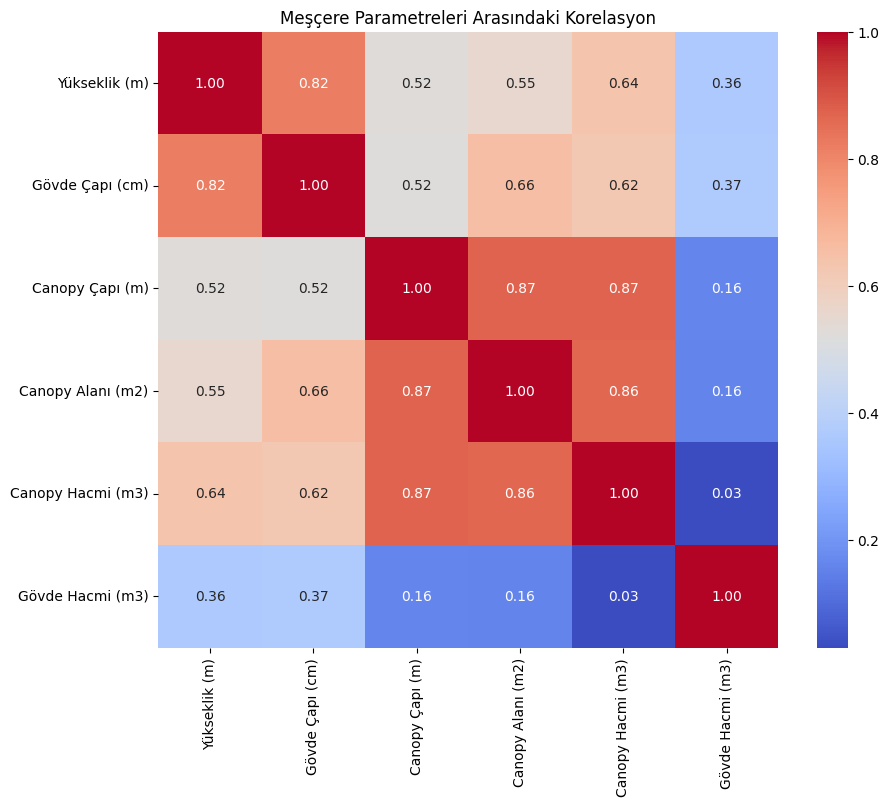

In [6]:
# 3. Korelasyon matrisini görselleştirme (Isı haritası)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Meşçere Parametreleri Arasındaki Korelasyon')
plt.show()

In [ ]:
# IQR hesaplama fonksiyonu
def detect_outliers_iqr(data, column_name):
    Q1 = data[column_name].quantile(0.25)  # İlk çeyrek
    Q3 = data[column_name].quantile(0.75)  # Üçüncü çeyrek
    IQR = Q3 - Q1                          # IQR hesaplama
    lower_bound = Q1 - 1.5 * IQR           # Alt sınır
    upper_bound = Q3 + 1.5 * IQR           # Üst sınır
    # Aykırı değerlerin filtrelenmesi
    outliers = data[(data[column_name] < lower_bound) | (data[column_name] > upper_bound)]
    return outliers

# Aykırı değerleri tespit etme
outliers_sütun1 = detect_outliers_iqr(data, 'Yükseklik (m)')
outliers_sütun2 = detect_outliers_iqr(data, 'Gövde Çapı (cm)')

print("Sütun 1 Aykırı Değerler:")
print(outliers_sütun1)

print("Sütun 2 Aykırı Değerler:")
print(outliers_sütun2)

Sütun 1 Aykırı Değerler:
Empty DataFrame
Columns: [treeID, Ağaç No, Yükseklik (m), Gövde Çapı (cm), Canopy Çapı (m), Canopy Alanı (m2), Canopy Hacmi (m3), Gövde Hacmi (m3)]
Index: []
Sütun 2 Aykırı Değerler:
Empty DataFrame
Columns: [treeID, Ağaç No, Yükseklik (m), Gövde Çapı (cm), Canopy Çapı (m), Canopy Alanı (m2), Canopy Hacmi (m3), Gövde Hacmi (m3)]
Index: []


In [ ]:
# Z-Skoru hesaplama
data['Yükseklik (m)'] = zscore(data['Yükseklik (m)'])
data['Gövde Çapı (cm)'] = zscore(data['Gövde Çapı (cm)'])

# Z-skoru sınırlarının dışına çıkan aykırı değerler
threshold = 3  # Tipik eşik değeri
outliers_param1_z = data[(data['Yükseklik (m)'] > threshold) | (data['Yükseklik (m)'] < -threshold)]
outliers_param2_z = data[(data['Gövde Çapı (cm)'] > threshold) | (data['Gövde Çapı (cm)'] < -threshold)]

print("Parametre 1 Z-Skoruna Göre Aykırı Değerler:")
print(outliers_param1_z)

print("Parametre 2 Z-Skoruna Göre Aykırı Değerler:")
print(outliers_param2_z)

Parametre 1 Z-Skoruna Göre Aykırı Değerler:
Empty DataFrame
Columns: [treeID, Ağaç No, Yükseklik (m), Gövde Çapı (cm), Canopy Çapı (m), Canopy Alanı (m2), Canopy Hacmi (m3), Gövde Hacmi (m3)]
Index: []
Parametre 2 Z-Skoruna Göre Aykırı Değerler:
Empty DataFrame
Columns: [treeID, Ağaç No, Yükseklik (m), Gövde Çapı (cm), Canopy Çapı (m), Canopy Alanı (m2), Canopy Hacmi (m3), Gövde Hacmi (m3)]
Index: []


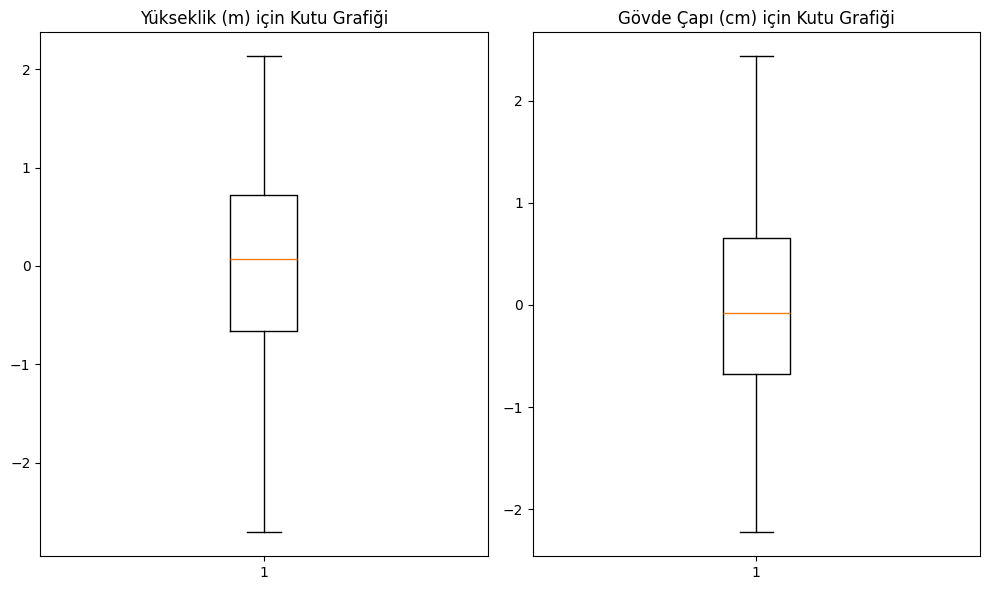

In [ ]:
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.boxplot(data['Yükseklik (m)'])
plt.title('Yükseklik (m) için Kutu Grafiği') # Changed to string literal

plt.subplot(1, 2, 2)
plt.boxplot(data['Gövde Çapı (cm)']) # Added quotes around column name
plt.title('Gövde Çapı (cm) için Kutu Grafiği') # Changed to string literal

plt.tight_layout()
plt.show()

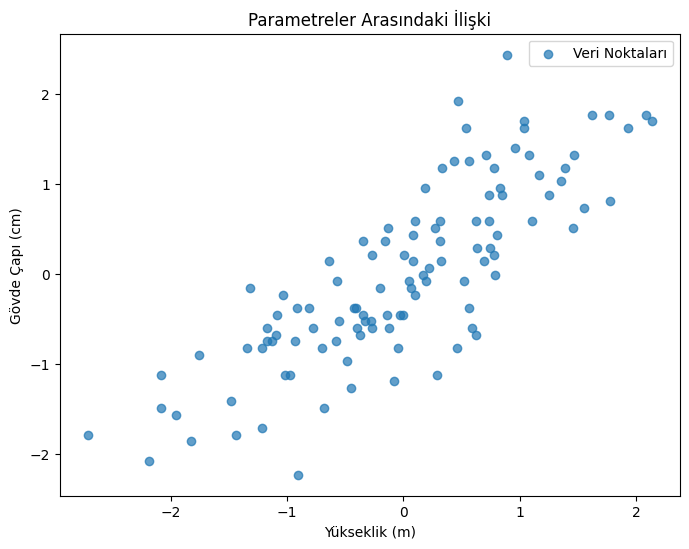

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(data['Yükseklik (m)'], data['Gövde Çapı (cm)'], alpha=0.7, label="Veri Noktaları")
plt.xlabel('Yükseklik (m)')
plt.ylabel('Gövde Çapı (cm)')
plt.title("Parametreler Arasındaki İlişki")
plt.legend()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [ ]:
# Bağımsız ve bağımlı değişkenler
X = data['Yükseklik (m)'].values.reshape(-1, 1)
y = data['Gövde Çapı (cm)'].values

In [ ]:
# Polinomsal özellikler oluşturma (derece 2 örneği)
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

In [ ]:
# Polinomsal regresyon modeli
model = LinearRegression()
model.fit(X_poly, y)

LinearRegression()

In [ ]:
# Tahminler
y_pred = model.predict(X_poly)

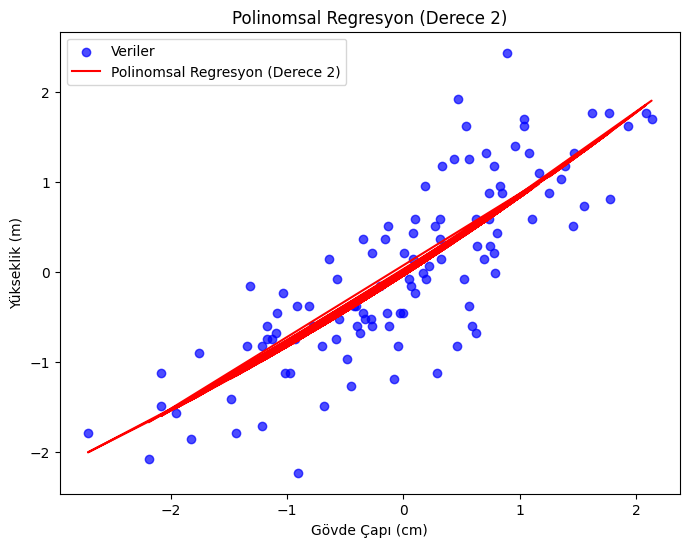

In [ ]:
# Görselleştirme
plt.figure(figsize=(8, 6))
plt.scatter(X, y, color='blue', label='Veriler', alpha=0.7)
plt.plot(X, y_pred, color='red', label='Polinomsal Regresyon (Derece 2)')
plt.xlabel('Gövde Çapı (cm)')
plt.ylabel('Yükseklik (m)')
plt.title('Polinomsal Regresyon (Derece 2)')
plt.legend()
plt.show()

In [ ]:
# R², MAE ve MSE hesaplama
r2 = r2_score(y, y_pred)
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)

print(f"R²: {r2:.2f}")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")

R²: 0.68
MAE: 0.44
MSE: 0.32


In [ ]:
from scipy.optimize import curve_fit

/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
<ipython-input-27-3cd993ee0da0>:6: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(log_model, data['Gövde Çapı (cm)'], data['Yükseklik (m)'])


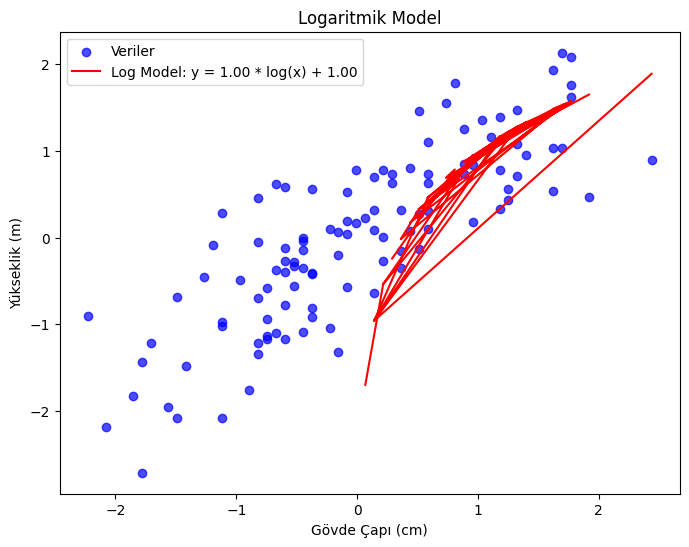

In [ ]:
# Doğrusal olmayan model: y = a * log(x) + b
def log_model(x, a, b):
    return a * np.log(x) + b

# Modelin parametrelerini tahmin etme
popt, pcov = curve_fit(log_model, data['Gövde Çapı (cm)'], data['Yükseklik (m)'])

# Tahmin edilen parametreler
a, b = popt

# Tahminler
y_pred_log = log_model(data['Gövde Çapı (cm)'], a, b)

# Görselleştirme
plt.figure(figsize=(8, 6))
plt.scatter(data['Gövde Çapı (cm)'], data['Yükseklik (m)'], color='blue', label='Veriler', alpha=0.7)
plt.plot(data['Gövde Çapı (cm)'], y_pred_log, color='red', label=f'Log Model: y = {a:.2f} * log(x) + {b:.2f}')
plt.xlabel('Gövde Çapı (cm)')
plt.ylabel('Yükseklik (m)')
plt.title('Logaritmik Model')
plt.legend()
plt.show()

In [ ]:
# Logaritmik fonksiyon tanımı
def log_model(x, a, b):
    return a * np.log(x) + b

# Pozitif değerlere filtreleme
data = data[data['Yükseklik (m)'] > 0]
data = data[data['Gövde Çapı (cm)'] > 0]

# Modelin parametrelerini tahmin etme
popt, pcov = curve_fit(log_model, data['Yükseklik (m)'], data['Gövde Çapı (cm)'])

# Tahmin edilen parametreler
a, b = popt
print(f"Logaritmik Model Parametreleri: a = {a:.2f}, b = {b:.2f}")

Logaritmik Model Parametreleri: a = 0.27, b = 1.09


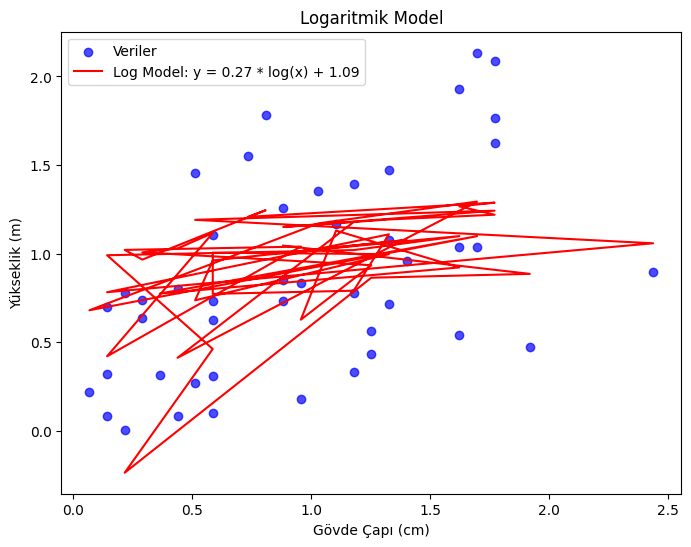

In [ ]:
# Tahminler
y_pred_log = log_model(data['Yükseklik (m)'], a, b)

# Görselleştirme
plt.figure(figsize=(8, 6))
plt.scatter(data['Gövde Çapı (cm)'], data['Yükseklik (m)'], color='blue', label='Veriler', alpha=0.7)
plt.plot(data['Gövde Çapı (cm)'], y_pred_log, color='red', label=f'Log Model: y = {a:.2f} * log(x) + {b:.2f}')
plt.xlabel('Gövde Çapı (cm)')
plt.ylabel('Yükseklik (m)')
plt.title('Logaritmik Model')
plt.legend()
plt.show()

In [ ]:
# R², MAE ve MSE hesaplama
r2 = r2_score(y, y_pred)
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)

print(f"R²: {r2:.2f}")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")

R²: 0.68
MAE: 0.44
MSE: 0.32


In [ ]:
from sklearn.ensemble import RandomForestRegressor

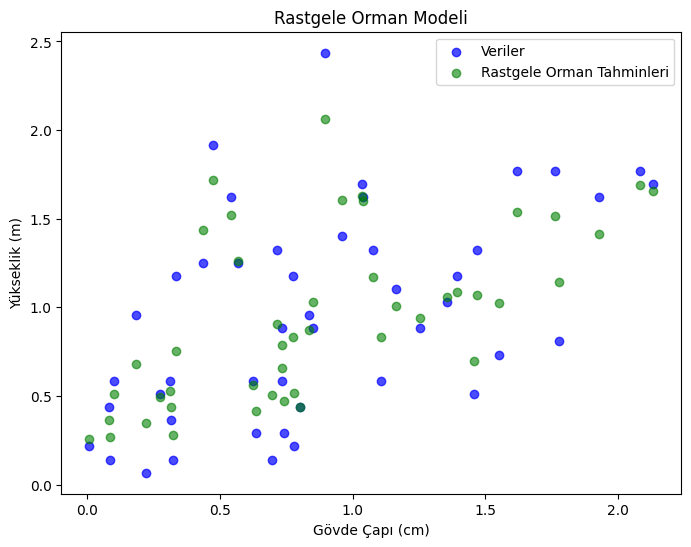

In [ ]:
X = data['Yükseklik (m)'].values.reshape(-1, 1)
y = data['Gövde Çapı (cm)'].values
# Model tanımlama ve eğitme
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X, y)

# Tahminler
y_pred_rf = rf_model.predict(X)

# Görselleştirme
plt.figure(figsize=(8, 6))
plt.scatter(X, y, color='blue', label='Veriler', alpha=0.7)
plt.scatter(X, y_pred_rf, color='green', label='Rastgele Orman Tahminleri', alpha=0.6)
plt.xlabel('Gövde Çapı (cm)')
plt.ylabel('Yükseklik (m)')
plt.title('Rastgele Orman Modeli')
plt.legend()
plt.show()

In [ ]:
# R², MAE ve MSE hesaplama
r2 = r2_score(y, y_pred_rf)
mae = mean_absolute_error(y, y_pred_rf)
mse = mean_squared_error(y, y_pred_rf)

print(f"R²: {r2:.2f}")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")

R²: 0.88
MAE: 0.16
MSE: 0.04


In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

Logaritmik Model Formülü: Gövde Çapı (cm) = 49.12 * log(Yükseklik (m)) + -97.41
Yükseklik 25 metre için tahmini Gövde Çapı: 60.69 cm


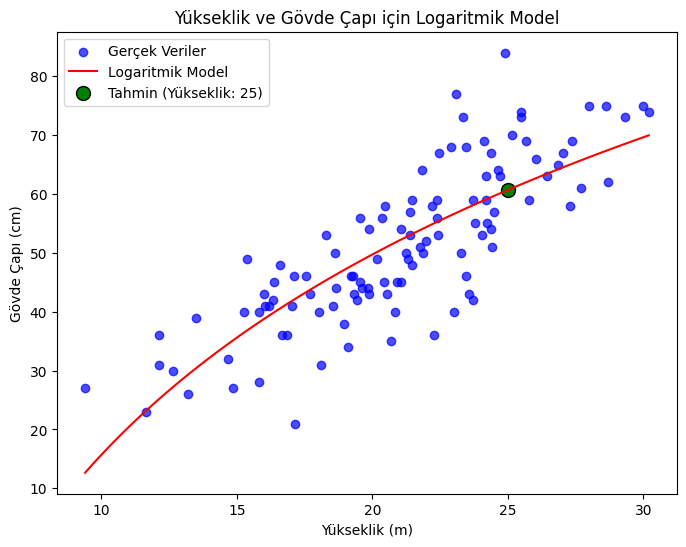

In [ ]:
# Logaritmik fonksiyon tanımı
def log_model(x, a, b):
    return a * np.log(x) + b

# Yükseklik ve gövde çapı değerlerini ayırma
X = data['Yükseklik (m)']
y = data['Gövde Çapı (cm)']

# Logaritmik modelin parametrelerini tahmin etme
popt, pcov = curve_fit(log_model, X, y)

# Tahmin edilen parametreler
a, b = popt
print(f"Logaritmik Model Formülü: Gövde Çapı (cm) = {a:.2f} * log(Yükseklik (m)) + {b:.2f}")

# Kullanıcıdan yükseklik değeri alarak gövde çapı tahmini
user_height = 25  # Örnek yükseklik değeri
predicted_diameter = log_model(user_height, a, b)
print(f"Yükseklik {user_height} metre için tahmini Gövde Çapı: {predicted_diameter:.2f} cm")

# Tahminleri görselleştirme
X_plot = np.linspace(min(X), max(X), 100)
y_plot = log_model(X_plot, a, b)

plt.figure(figsize=(8, 6))
plt.scatter(X, y, color='blue', label='Gerçek Veriler', alpha=0.7)
plt.plot(X_plot, y_plot, color='red', label='Logaritmik Model')
plt.scatter(user_height, predicted_diameter, color='green', label=f'Tahmin (Yükseklik: {user_height})', s=100, edgecolor='black')
plt.xlabel('Yükseklik (m)')
plt.ylabel('Gövde Çapı (cm)')
plt.title('Yükseklik ve Gövde Çapı için Logaritmik Model')
plt.legend()
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

Model Performansı:
MAE: 9.50
MSE: 161.06
R²: 0.52
Yükseklik 25 metre için tahmini Gövde Çapı: 67.67 cm


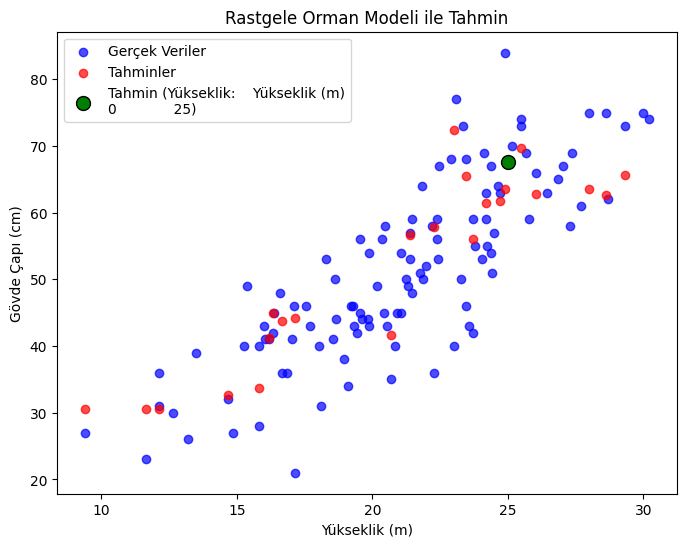

In [ ]:
# Bağımsız ve bağımlı değişkenler
X = data[['Yükseklik (m)']]  # Yükseklik (Bağımsız değişken)
y = data['Gövde Çapı (cm)']  # Gövde Çapı (Bağımlı değişken)

# Eğitim ve test veri setlerini ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Rastgele Orman modeli oluşturma ve eğitme
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Test verisi üzerinde tahmin
y_pred = rf_model.predict(X_test)

# Performans metrikleri
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Model Performansı:\nMAE: {mae:.2f}\nMSE: {mse:.2f}\nR²: {r2:.2f}")

# Kullanıcıdan yükseklik değeri alarak tahmin
user_height = pd.DataFrame({'Yükseklik (m)': [25]})  # Pandas DataFrame olarak oluşturma
predicted_diameter = rf_model.predict(user_height)
print(f"Yükseklik 25 metre için tahmini Gövde Çapı: {predicted_diameter[0]:.2f} cm")

# Görselleştirme
plt.figure(figsize=(8, 6))
plt.scatter(X, y, color='blue', label='Gerçek Veriler', alpha=0.7)
plt.scatter(X_test, y_pred, color='red', label='Tahminler', alpha=0.7)
plt.scatter(user_height, predicted_diameter, color='green', label=f'Tahmin (Yükseklik: {user_height})', s=100, edgecolor='black')
plt.xlabel('Yükseklik (m)')
plt.ylabel('Gövde Çapı (cm)')
plt.title('Rastgele Orman Modeli ile Tahmin')
plt.legend()
plt.show()

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import matplotlib.pyplot as plt

Model Performansı:
MAE: 9.98
MSE: 166.27
R²: 0.50
Yükseklik 25 metre için tahmini Gövde Çapı: 63.97 cm


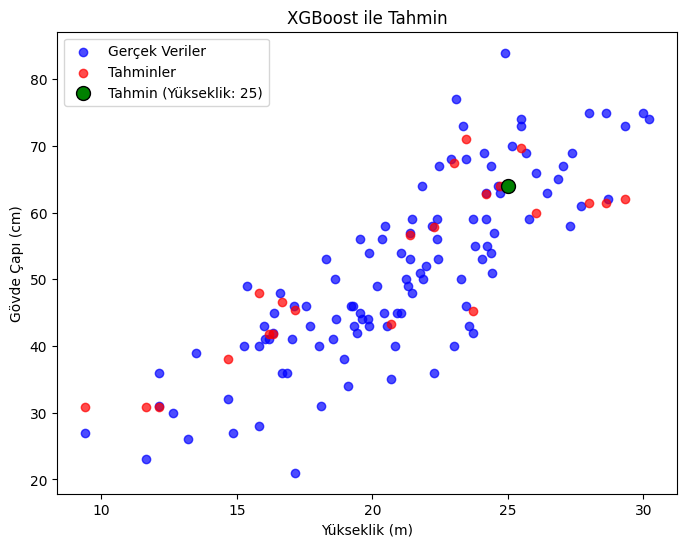

In [ ]:
# Bağımsız ve bağımlı değişkenler
X = data[['Yükseklik (m)']]  # Yükseklik (Bağımsız değişken)
y = data['Gövde Çapı (cm)']  # Gövde Çapı (Bağımlı değişken)

# Eğitim ve test veri setlerini ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# XGBoost modeli oluşturma ve eğitme
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

# Test verisi üzerinde tahmin
y_pred = xgb_model.predict(X_test)

# Performans metrikleri
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Model Performansı:\nMAE: {mae:.2f}\nMSE: {mse:.2f}\nR²: {r2:.2f}")

# Kullanıcıdan yükseklik değeri alarak tahmin
user_height = pd.DataFrame({'Yükseklik (m)': [25]})  # Örnek yükseklik değeri
predicted_diameter = xgb_model.predict(user_height)
print(f"Yükseklik {user_height.values[0][0]} metre için tahmini Gövde Çapı: {predicted_diameter[0]:.2f} cm")

# Görselleştirme
plt.figure(figsize=(8, 6))
plt.scatter(X, y, color='blue', label='Gerçek Veriler', alpha=0.7)
plt.scatter(X_test, y_pred, color='red', label='Tahminler', alpha=0.7)
plt.scatter(user_height, predicted_diameter, color='green', label=f'Tahmin (Yükseklik: {user_height.values[0][0]})', s=100, edgecolor='black')
plt.xlabel('Yükseklik (m)')
plt.ylabel('Gövde Çapı (cm)')
plt.title('XGBoost ile Tahmin')
plt.legend()
plt.show()

In [ ]:
a = data[['Yükseklik (m)']]
b = data['Gövde Çapı (cm)']


In [ ]:
data[['Yükseklik (m)']]

,Yükseklik (m)
0,17.152
1,20.356
2,21.332
3,23.561
4,12.115
...,...
106,19.546
107,21.240
108,23.069
109,24.696


In [ ]:
# Yükseklik ve Gövde Çapı için Z-Skoru hesaplama
data['zscore_height'] = zscore(a)
data['zscore_diameter'] = zscore(b)

# Aykırı değerleri filtreleme
outliers = data[(data['zscore_height'].abs() > 3) | (data['zscore_diameter'].abs() > 3)]
print("Aykırı değerler:")
print(outliers)

Aykırı değerler:
Empty DataFrame
Columns: [treeID, Ağaç No, Yükseklik (m), Gövde Çapı (cm), Canopy Çapı (m), Canopy Alanı (m2), Canopy Hacmi (m3), Gövde Hacmi (m3), zscore_height, zscore_diameter]
Index: []


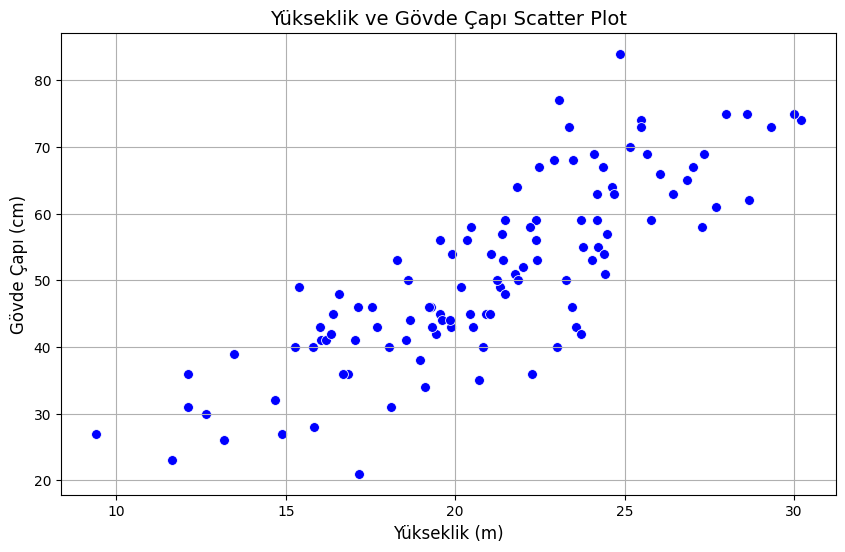

Manuel olarak seçilen aykırı değerler:
     Yükseklik (m)  Gövde Çapı (cm)
0           17.152               21
1           20.356               56
2           21.332               49
3           23.561               43
5           16.388               45
..             ...              ...
105         20.481               58
106         19.546               56
107         21.240               50
109         24.696               63
110         21.041               45

[91 rows x 2 columns]


In [ ]:
# Paylaşılan veri setini yeniden tanımlama
data = pd.DataFrame({
    'Yükseklik (m)': [17.152, 20.356, 21.332, 23.561, 12.115, 16.388, 19.427, 27.016, 21.392, 30.197, 23.701, 23.447, 11.645, 26.855, 18.608, 16.581, 17.555, 16.844, 16.679, 19.542, 18.283, 17.700, 19.891, 21.990, 15.388, 12.635, 17.121, 20.162, 19.280, 13.190, 25.490, 22.386, 19.615, 23.360, 24.409, 23.282, 26.039, 15.273, 21.820, 18.103, 19.114, 19.316, 14.686, 23.470, 13.485, 9.402, 15.828, 18.556, 16.026, 24.217, 17.034, 24.484, 20.824, 25.793, 20.442, 19.219, 21.403, 24.622, 24.383, 12.113, 23.770, 28.679, 27.703, 29.991, 29.325, 28.001, 27.348, 26.427, 28.616, 27.296, 16.194, 14.877, 24.878, 22.424, 25.666, 22.468, 22.377, 21.774, 24.196, 20.699, 22.271, 23.018, 24.102, 22.209, 16.340, 23.723, 25.154, 24.189, 25.496, 18.653, 19.884, 21.863, 21.481, 20.899, 20.527, 18.950, 15.806, 18.039, 24.371, 24.032, 21.463, 16.005, 19.841, 21.071, 22.912, 20.481, 19.546, 21.240, 23.069, 24.696, 21.041],
    'Gövde Çapı (cm)': [21, 56, 49, 43, 36, 45, 42, 67, 57, 74, 42, 46, 23, 65, 50, 48, 46, 36, 36, 45, 53, 43, 54, 52, 49, 30, 46, 49, 46, 26, 74, 56, 44, 73, 51, 50, 66, 40, 64, 31, 34, 43, 32, 68, 39, 27, 28, 41, 41, 55, 41, 57, 40, 59, 45, 46, 53, 64, 54, 31, 55, 62, 61, 75, 73, 75, 69, 63, 75, 58, 41, 27, 84, 53, 69, 67, 59, 51, 59, 35, 36, 40, 69, 58, 42, 59, 70, 63, 73, 44, 43, 50, 48, 45, 43, 38, 40, 40, 67, 53, 59, 43, 44, 54, 68, 58, 56, 50, 77, 63, 45]
})

# Scatter plot ile Yükseklik ve Gövde Çapı arasındaki ilişkiyi görselleştirme
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='Yükseklik (m)', y='Gövde Çapı (cm)', color='blue', s=50)
plt.title('Yükseklik ve Gövde Çapı Scatter Plot', fontsize=14)
plt.xlabel('Yükseklik (m)', fontsize=12)
plt.ylabel('Gövde Çapı (cm)', fontsize=12)
plt.grid(True)
plt.show()

# Açıklama: Scatter plot üzerindeki uç noktaları görsel olarak inceleyerek korelasyonu bozduğunu düşündüğünüz noktaları belirleyebilirsiniz.
# Eğer belirli bir değer seçmek isterseniz, `data` DataFrame'i kullanarak manuel bir filtre uygulayabilirsiniz.

# Örnek: Belirli bir Yükseklik ve Gövde Çapı eşleşmesini manuel olarak filtreleme
outlier_manual = data[(data['Yükseklik (m)'] > 15) & (data['Gövde Çapı (cm)'] < 70)]
print("Manuel olarak seçilen aykırı değerler:")
print(outlier_manual)

Regresyon eğrisinin uzağında kalan değerler:
     Yükseklik (m)  Gövde Çapı (cm)
0           17.152               21
10          23.701               42
33          23.360               73
72          24.878               84
80          22.271               36
81          23.018               40
108         23.069               77


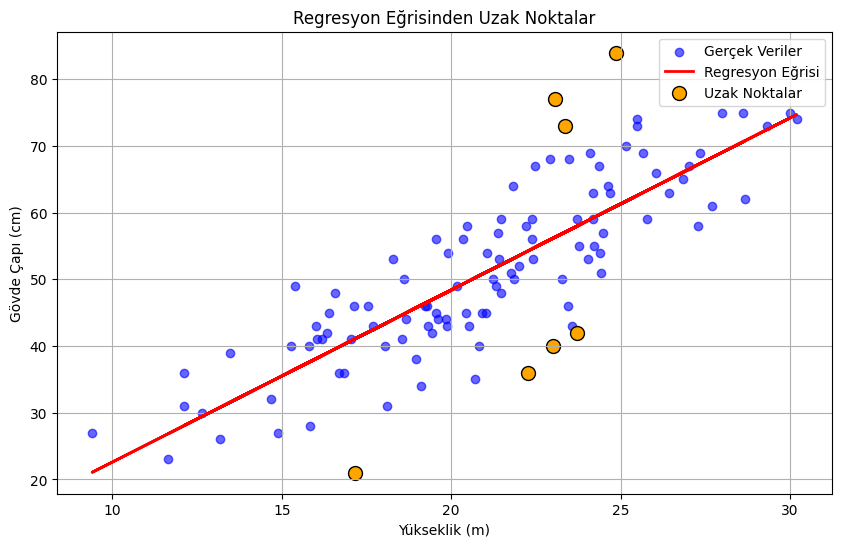

In [ ]:
# Veri setini tanımlama
X = data[['Yükseklik (m)']].values  # Bağımsız değişken
y = data['Gövde Çapı (cm)'].values  # Bağımlı değişken

# Doğrusal regresyon modeli oluşturma
model = LinearRegression()
model.fit(X, y)

# Tahmin edilen değerleri hesaplama
y_pred = model.predict(X)

# Sapmaları hesaplama
residuals = y - y_pred

# Sapmalar için eşik belirleme (Z-skoru)
z_scores = (residuals - np.mean(residuals)) / np.std(residuals)
threshold = 2  # Z-skoru için eşik (örneğin, 3)

# Uzak noktaları tespit etme
outliers = data[np.abs(z_scores) > threshold]

print("Regresyon eğrisinin uzağında kalan değerler:")
print(outliers)

# Regresyon eğrisini ve uzak noktaları görselleştirme
plt.figure(figsize=(10, 6))
plt.scatter(X, y, label='Gerçek Veriler', color='blue', alpha=0.6)
plt.plot(X, y_pred, label='Regresyon Eğrisi', color='red', linewidth=2)
plt.scatter(X[np.abs(z_scores) > threshold], y[np.abs(z_scores) > threshold],
            label='Uzak Noktalar', color='orange', edgecolor='black', s=100)
plt.xlabel('Yükseklik (m)')
plt.ylabel('Gövde Çapı (cm)')
plt.title('Regresyon Eğrisinden Uzak Noktalar')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
thresholds = [1.5, 2, 3]

for threshold in thresholds:
    outliers = data[np.abs(z_scores) > threshold]
    print(f"Z-Skoru Eşiği: {threshold}")
    print(f"Uç Nokta Sayısı: {len(outliers)}")
    print(outliers)
    print("-" * 50)

Z-Skoru Eşiği: 1.5
Uç Nokta Sayısı: 14
     Yükseklik (m)  Gövde Çapı (cm)
0           17.152               21
3           23.561               43
10          23.701               42
24          15.388               49
33          23.360               73
39          18.103               31
40          19.114               34
72          24.878               84
75          22.468               67
79          20.699               35
80          22.271               36
81          23.018               40
104         22.912               68
108         23.069               77
--------------------------------------------------
Z-Skoru Eşiği: 2
Uç Nokta Sayısı: 7
     Yükseklik (m)  Gövde Çapı (cm)
0           17.152               21
10          23.701               42
33          23.360               73
72          24.878               84
80          22.271               36
81          23.018               40
108         23.069               77
----------------------------------------------

In [7]:
data = pd.read_excel('Ladin-1-5.xlsx')

In [8]:
data

,treeID,Ağaç No,Yükseklik (m),Gövde Çapı (cm),Canopy Çapı (m),Canopy Alanı (m2),Canopy Hacmi (m3),Gövde Hacmi (m3)
0,828,L.23,20.356,56,7.947,33.537,308.210,0.348
1,1164,L.24,21.332,49,7.592,32.850,260.453,0.574
2,1252,L.14,12.115,36,6.616,17.264,97.245,0.172
3,280,L.15,16.388,45,7.621,22.621,188.025,0.596
4,597,L.129,19.427,42,6.407,18.271,174.289,0.211
...,...,...,...,...,...,...,...,...
92,941,L.397,20.481,58,7.020,20.659,186.220,1.217
93,740,L.395,19.546,56,6.945,22.786,184.563,0.660
94,60,L.396,21.240,50,8.190,27.357,291.337,0.491
95,400,L.309,24.696,63,10.032,47.046,464.137,0.392


In [9]:
# 1. Korelasyon matrisi oluşturma
selected_columns = ['Yükseklik (m)', 'Gövde Çapı (cm)', 'Canopy Çapı (m)', 'Canopy Alanı (m2)', 'Canopy Hacmi (m3)', 'Gövde Hacmi (m3)']
correlation_matrix = data[selected_columns].corr()


In [10]:
# 2. Korelasyon matrisini yazdırma
print("Korelasyon Matrisi:")
print(correlation_matrix)

Korelasyon Matrisi:
                   Yükseklik (m)  Gövde Çapı (cm)  Canopy Çapı (m)  \
Yükseklik (m)           1.000000         0.897250         0.589480   
Gövde Çapı (cm)         0.897250         1.000000         0.619092   
Canopy Çapı (m)         0.589480         0.619092         1.000000   
Canopy Alanı (m2)       0.592042         0.652184         0.903056   
Canopy Hacmi (m3)       0.703739         0.688528         0.844488   
Gövde Hacmi (m3)        0.349290         0.356333         0.181953   

                   Canopy Alanı (m2)  Canopy Hacmi (m3)  Gövde Hacmi (m3)  
Yükseklik (m)               0.592042           0.703739          0.349290  
Gövde Çapı (cm)             0.652184           0.688528          0.356333  
Canopy Çapı (m)             0.903056           0.844488          0.181953  
Canopy Alanı (m2)           1.000000           0.846581          0.144190  
Canopy Hacmi (m3)           0.846581           1.000000          0.009762  
Gövde Hacmi (m3)            0.144

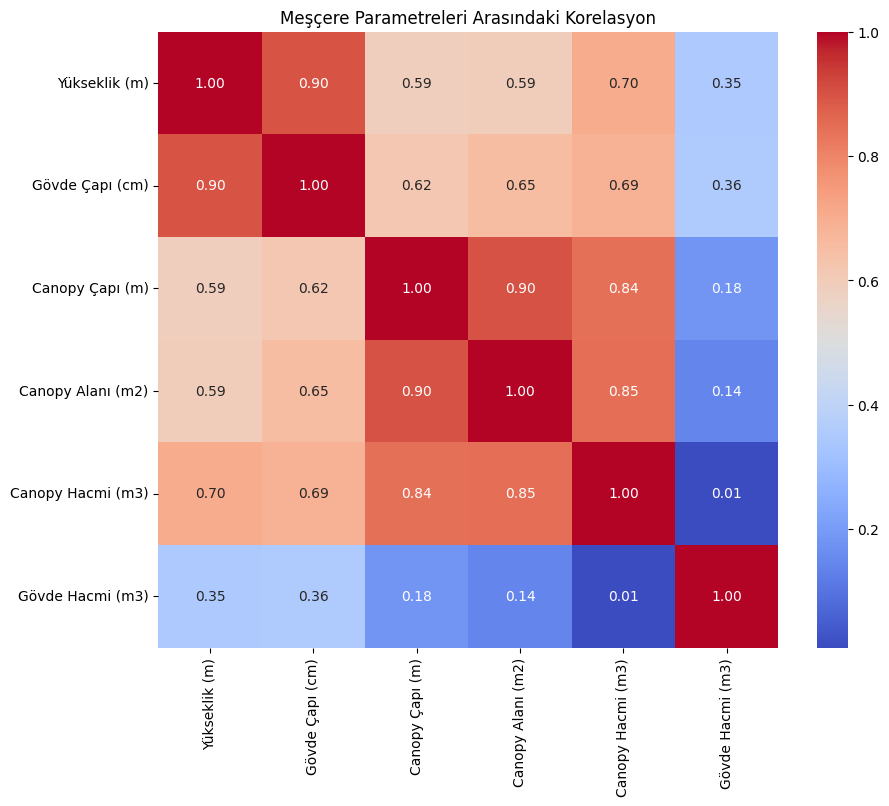

In [11]:
# 3. Korelasyon matrisini görselleştirme (Isı haritası)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Meşçere Parametreleri Arasındaki Korelasyon')
plt.show()

Regresyon Formülü: Gövde Çapı (cm) = 2.51 * Yükseklik (m) + -1.35
Yükseklik 25 metre için tahmini Gövde Çapı: 61.31 cm


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


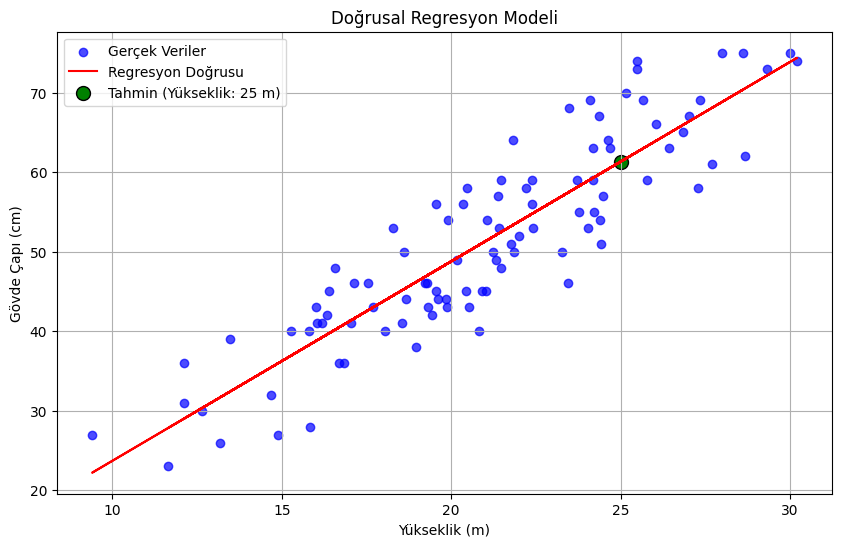

In [12]:
# Bağımsız ve bağımlı değişkenleri ayırma
X = data[['Yükseklik (m)']]  # Bağımsız değişken (X)
y = data['Gövde Çapı (cm)']  # Bağımlı değişken (y)

# Doğrusal regresyon modeli oluşturma ve eğitme
model = LinearRegression()
model.fit(X, y)

# Modelin katsayılarını ve kesişimini öğrenme
a = model.coef_[0]  # Katsayı
b = model.intercept_  # Kesişim noktası
print(f"Regresyon Formülü: Gövde Çapı (cm) = {a:.2f} * Yükseklik (m) + {b:.2f}")

# Örnek bir yükseklik değeri için gövde çapını tahmin etme
user_height = 25  # Örnek yükseklik değeri
predicted_diameter = model.predict([[user_height]])
print(f"Yükseklik {user_height} metre için tahmini Gövde Çapı: {predicted_diameter[0]:.2f} cm")

# Gerçek veriler ve regresyon doğrusu ile görselleştirme
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Gerçek Veriler', alpha=0.7)
plt.plot(X, model.predict(X), color='red', label='Regresyon Doğrusu')
plt.scatter(user_height, predicted_diameter, color='green', label=f'Tahmin (Yükseklik: {user_height} m)', s=100, edgecolor='black')
plt.xlabel('Yükseklik (m)')
plt.ylabel('Gövde Çapı (cm)')
plt.title('Doğrusal Regresyon Modeli')
plt.legend()
plt.grid(True)
plt.show()

Regresyon Formülü: Gövde Çapı (cm) = 2.51 * Yükseklik (m) + -1.36

Model Performansı:
R²: 0.71
MAE: 5.22 (Ortalama Mutlak Hata)
MSE: 36.15 (Ortalama Kare Hata)
Yükseklik 25 metre için tahmini Gövde Çapı: 61.40 cm


<ipython-input-12-4cc8116f3084>:42: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  plt.text(x=float(X.min()), y=float(y.max()), s=f"$R^2$: {r2:.2f}\nMAE: {mae:.2f}", fontsize=12, color='black', bbox=dict(facecolor='white', alpha=0.5))


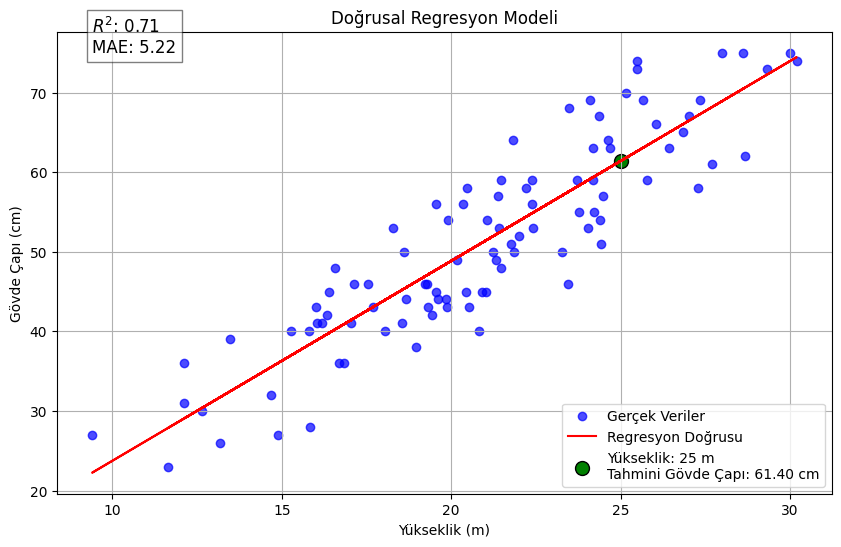

In [ ]:
# Bağımsız ve bağımlı değişkenleri ayırma
X = data[['Yükseklik (m)']]  # Bağımsız değişken (X)
y = data['Gövde Çapı (cm)']  # Bağımlı değişken (y)

# Eğitim ve test veri setlerini ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Doğrusal regresyon modeli oluşturma ve eğitme
model = LinearRegression()
model.fit(X_train, y_train)

# Modelin katsayılarını ve kesişimini öğrenme
a = model.coef_[0]  # Katsayı
b = model.intercept_  # Kesişim noktası
print(f"Regresyon Formülü: Gövde Çapı (cm) = {a:.2f} * Yükseklik (m) + {b:.2f}")

# Test setinde tahminler yapma
y_pred = model.predict(X_test)

# Performans metriklerini hesaplama
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

# Performans metriklerini yazdırma
print(f"\nModel Performansı:")
print(f"R²: {r2:.2f}")
print(f"MAE: {mae:.2f} (Ortalama Mutlak Hata)")
print(f"MSE: {mse:.2f} (Ortalama Kare Hata)")

# Kullanıcıdan yükseklik değeri alarak tahmin
user_height = pd.DataFrame({'Yükseklik (m)': [25]})  # Pandas DataFrame olarak oluşturma
predicted_diameter = model.predict(user_height)
print(f"Yükseklik 25 metre için tahmini Gövde Çapı: {predicted_diameter[0]:.2f} cm")

# Gerçek veriler ve regresyon doğrusu ile görselleştirme
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Gerçek Veriler', alpha=0.7)
plt.plot(X, model.predict(X), color='red', label='Regresyon Doğrusu')

# R² değerini grafiğin üzerine ekleme
plt.text(x=float(X.min()), y=float(y.max()), s=f"$R^2$: {r2:.2f}\nMAE: {mae:.2f}", fontsize=12, color='black', bbox=dict(facecolor='white', alpha=0.5))

# Örnek bir yükseklik değeri için tahmini gösterme
plt.scatter(user_height, predicted_diameter, color='green', label=f'Yükseklik: 25 m\nTahmini Gövde Çapı: {predicted_diameter[0]:.2f} cm', s=100, edgecolor='black')

plt.xlabel('Yükseklik (m)')
plt.ylabel('Gövde Çapı (cm)')
plt.title('Doğrusal Regresyon Modeli')
plt.legend()
plt.grid(True)
plt.show()

Polinomsal Regresyon Modeli Performansı (Derece 2):
R²: 0.71
MAE: 5.23 (Ortalama Mutlak Hata)
MSE: 36.37 (Ortalama Kare Hata)

Polinomsal Regresyon Denklemine Göre:
y = 5.48 + 0.00 + 1.81 * x^1 + 0.02 * x^2

Yükseklik 25 metre için tahmini Gövde Çapı: 61.37 cm


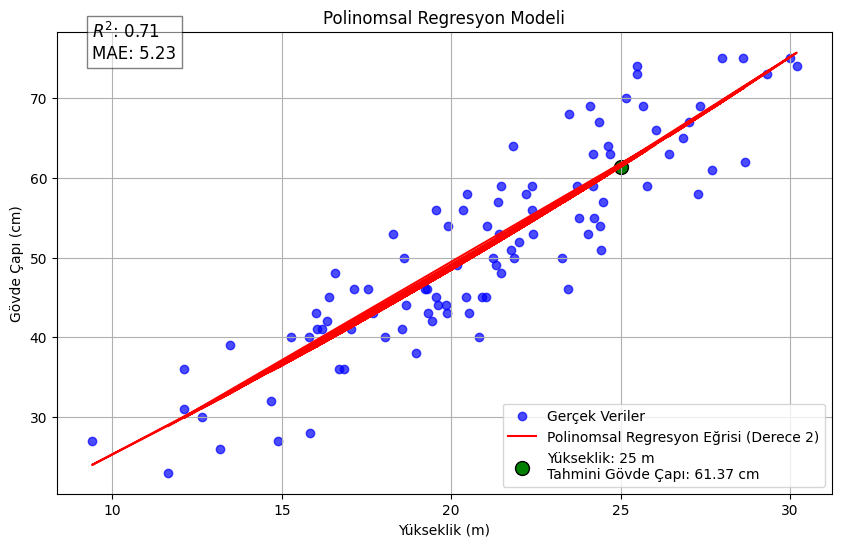

In [ ]:
# Bağımsız ve bağımlı değişkenleri ayırma
X = data[['Yükseklik (m)']].values  # Bağımsız değişken
y = data['Gövde Çapı (cm)'].values  # Bağımlı değişken

# Eğitim ve test veri setlerini ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Polinomsal özellikler oluşturma (derece 2)
degree = 2
poly_features = PolynomialFeatures(degree=degree)
X_poly_train = poly_features.fit_transform(X_train)
X_poly_test = poly_features.transform(X_test)

# Polinomsal regresyon modeli oluşturma ve eğitme
poly_model = LinearRegression()
poly_model.fit(X_poly_train, y_train)

# Tahminler yapma
y_pred = poly_model.predict(X_poly_test)

# Performans metriklerini hesaplama
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

# Model performansını yazdırma
print(f"Polinomsal Regresyon Modeli Performansı (Derece {degree}):")
print(f"R²: {r2:.2f}")
print(f"MAE: {mae:.2f} (Ortalama Mutlak Hata)")
print(f"MSE: {mse:.2f} (Ortalama Kare Hata)")

# Polinomsal regresyon denklemini oluşturma
coefficients = poly_model.coef_
intercept = poly_model.intercept_
print("\nPolinomsal Regresyon Denklemine Göre:")
formula_terms = [f"{coefficients[i]:.2f} * x^{i}" if i > 0 else f"{coefficients[i]:.2f}" for i in range(len(coefficients))]
formula = " + ".join(formula_terms)
formula = f"y = {intercept:.2f} + {formula}"
print(formula)

# Örnek bir yükseklik değeri için tahmini gövde çapı hesaplama
user_height = 25  # Örnek yükseklik değeri
user_height_poly = poly_features.transform([[user_height]])
predicted_diameter = poly_model.predict(user_height_poly)
print(f"\nYükseklik {user_height} metre için tahmini Gövde Çapı: {predicted_diameter[0]:.2f} cm")

# Gerçek veriler ve polinomsal regresyon eğrisi ile görselleştirme
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Gerçek Veriler', alpha=0.7)

# Polinomsal regresyon eğrisini çizme
X_curve = poly_features.fit_transform(X)
y_curve = poly_model.predict(X_curve)
plt.plot(X, y_curve, color='red', label=f'Polinomsal Regresyon Eğrisi (Derece {degree})')

# R² değerini grafiğin üzerine ekleme
plt.text(x=float(X.min()), y=float(y.max()), s=f"$R^2$: {r2:.2f}\nMAE: {mae:.2f}", fontsize=12, color='black', bbox=dict(facecolor='white', alpha=0.5))

# Örnek bir yükseklik değeri için tahmini gösterme
plt.scatter(user_height, predicted_diameter, color='green', label=f'Yükseklik: 25 m\nTahmini Gövde Çapı: {predicted_diameter[0]:.2f} cm', s=100, edgecolor='black')


plt.xlabel('Yükseklik (m)')
plt.ylabel('Gövde Çapı (cm)')
plt.title('Polinomsal Regresyon Modeli')
plt.legend()
plt.grid(True)
plt.show()

Logaritmik Regresyon Modeli Performansı:
R²: 0.70
MAE: 5.31 (Ortalama Mutlak Hata)
MSE: 37.17 (Ortalama Kare Hata)
Regresyon Denklemi: Gövde Çapı = 47.37 * log(Yükseklik) + -91.60

Yükseklik 25 metre için tahmini Gövde Çapı: 60.89 cm


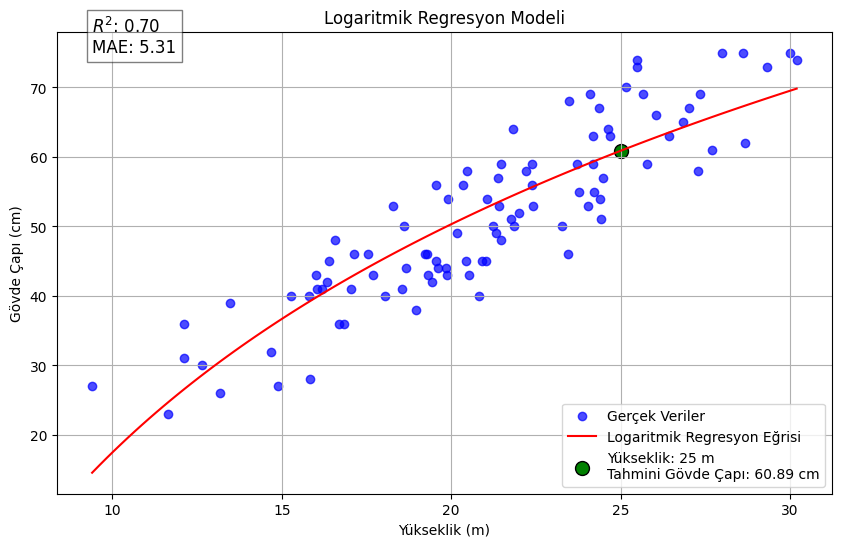

In [ ]:
# Bağımsız ve bağımlı değişkenleri ayırma
X = data[['Yükseklik (m)']].values  # Bağımsız değişken (X)
y = data['Gövde Çapı (cm)'].values  # Bağımlı değişken (y)

# Logaritmik dönüşüm (X için)
X_log = np.log(X)

# Eğitim ve test veri setlerini ayırma
X_train, X_test, y_train, y_test = train_test_split(X_log, y, test_size=0.2, random_state=42)

# Logaritmik regresyon modeli oluşturma ve eğitme
log_model = LinearRegression()
log_model.fit(X_train, y_train)

# Tahminler yapma
y_pred = log_model.predict(X_test)

# Performans metriklerini hesaplama
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

# Model performansını yazdırma
print(f"Logaritmik Regresyon Modeli Performansı:")
print(f"R²: {r2:.2f}")
print(f"MAE: {mae:.2f} (Ortalama Mutlak Hata)")
print(f"MSE: {mse:.2f} (Ortalama Kare Hata)")

# Regresyon denklemi
a = log_model.coef_[0]
b = log_model.intercept_
print(f"Regresyon Denklemi: Gövde Çapı = {a:.2f} * log(Yükseklik) + {b:.2f}")

# Örnek bir yükseklik değeri için tahmini gövde çapı hesaplama
user_height = 25  # Örnek yükseklik değeri
predicted_diameter = log_model.predict([[np.log(user_height)]])
print(f"\nYükseklik {user_height} metre için tahmini Gövde Çapı: {predicted_diameter[0]:.2f} cm")

# Gerçek veriler ve logaritmik regresyon eğrisi ile görselleştirme
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Gerçek Veriler', alpha=0.7)

# Logaritmik regresyon eğrisini çizme
X_curve = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_curve_log = np.log(X_curve)
y_curve = log_model.predict(X_curve_log)
plt.plot(X_curve, y_curve, color='red', label='Logaritmik Regresyon Eğrisi')

# R² değerini grafiğin üzerine ekleme
plt.text(x=float(X.min()), y=float(y.max()), s=f"$R^2$: {r2:.2f}\nMAE: {mae:.2f}", fontsize=12, color='black', bbox=dict(facecolor='white', alpha=0.5))

# Örnek bir yükseklik değeri için tahmini gösterme
plt.scatter(user_height, predicted_diameter, color='green', label=f'Yükseklik: 25 m\nTahmini Gövde Çapı: {predicted_diameter[0]:.2f} cm', s=100, edgecolor='black')

plt.xlabel('Yükseklik (m)')
plt.ylabel('Gövde Çapı (cm)')
plt.title('Logaritmik Regresyon Modeli')
plt.legend()
plt.grid(True)
plt.show()

Random Forest Regresyon Modeli Performansı:
R²: 0.70
MAE: 5.21 (Ortalama Mutlak Hata)
MSE: 36.88 (Ortalama Kare Hata)

Yükseklik 25 metre için tahmini Gövde Çapı: 67.42 cm


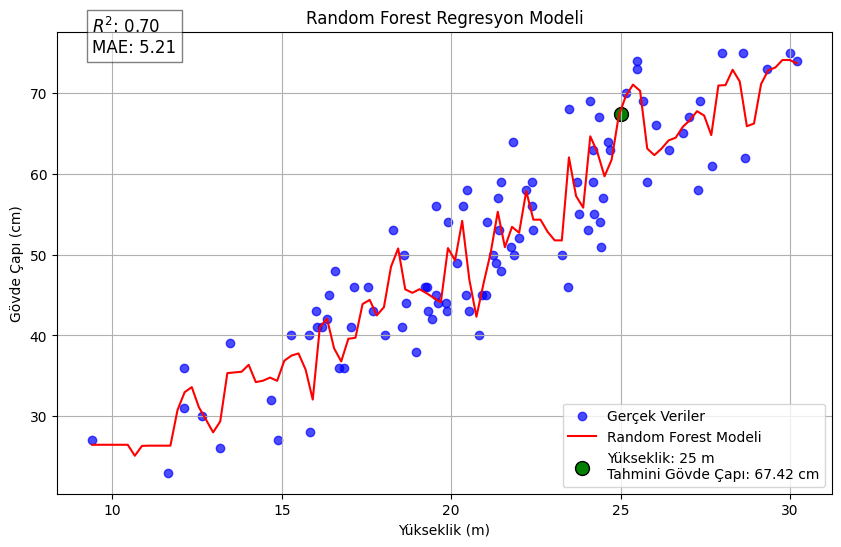

In [ ]:
# Bağımsız ve bağımlı değişkenleri ayırma
X = data[['Yükseklik (m)']].values  # Bağımsız değişken (X)
y = data['Gövde Çapı (cm)'].values  # Bağımlı değişken (y)

# Eğitim ve test veri setlerini ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest regresyon modeli oluşturma ve eğitme
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Tahminler yapma
y_pred = rf_model.predict(X_test)

# Performans metriklerini hesaplama
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

# Model performansını yazdırma
print(f"Random Forest Regresyon Modeli Performansı:")
print(f"R²: {r2:.2f}")
print(f"MAE: {mae:.2f} (Ortalama Mutlak Hata)")
print(f"MSE: {mse:.2f} (Ortalama Kare Hata)")

# Örnek bir yükseklik değeri için tahmini gövde çapı hesaplama
user_height = 25  # Örnek yükseklik değeri
predicted_diameter = rf_model.predict([[user_height]])
print(f"\nYükseklik {user_height} metre için tahmini Gövde Çapı: {predicted_diameter[0]:.2f} cm")

# Gerçek veriler ve random forest regresyonu ile görselleştirme
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Gerçek Veriler', alpha=0.7)

# Random Forest modelinin regresyon doğrusu
X_curve = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_curve = rf_model.predict(X_curve)
plt.plot(X_curve, y_curve, color='red', label='Random Forest Modeli')

# R² değerini grafiğin üzerine ekleme
plt.text(x=float(X.min()), y=float(y.max()), s=f"$R^2$: {r2:.2f}\nMAE: {mae:.2f}", fontsize=12, color='black', bbox=dict(facecolor='white', alpha=0.5))

# Örnek bir yükseklik değeri için tahmini gösterme
plt.scatter(user_height, predicted_diameter, color='green', label=f'Yükseklik: 25 m\nTahmini Gövde Çapı: {predicted_diameter[0]:.2f} cm', s=100, edgecolor='black')

plt.xlabel('Yükseklik (m)')
plt.ylabel('Gövde Çapı (cm)')
plt.title('Random Forest Regresyon Modeli')
plt.legend()
plt.grid(True)
plt.show()

Destek Vektör Regresyon Modeli Performansı:
R²: 0.71
MAE: 4.86 (Ortalama Mutlak Hata)
MSE: 35.76 (Ortalama Kare Hata)

Yükseklik 25 metre için tahmini Gövde Çapı: 62.95 cm


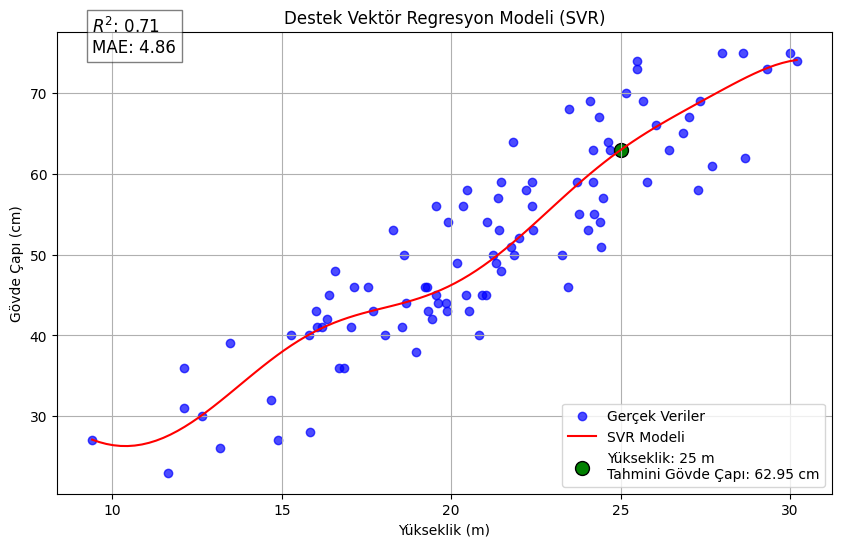

In [ ]:
# Bağımsız ve bağımlı değişkenleri ayırma
X = data[['Yükseklik (m)']].values  # Bağımsız değişken (X)
y = data['Gövde Çapı (cm)'].values  # Bağımlı değişken (y)

# Eğitim ve test veri setlerini ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Destek vektör regresyon modeli oluşturma ve eğitme
svr_model = SVR(kernel='rbf', C=100, epsilon=0.1)
svr_model.fit(X_train, y_train)

# Tahminler yapma
y_pred = svr_model.predict(X_test)

# Performans metriklerini hesaplama
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

# Model performansını yazdırma
print(f"Destek Vektör Regresyon Modeli Performansı:")
print(f"R²: {r2:.2f}")
print(f"MAE: {mae:.2f} (Ortalama Mutlak Hata)")
print(f"MSE: {mse:.2f} (Ortalama Kare Hata)")

# Örnek bir yükseklik değeri için tahmini gövde çapı hesaplama
user_height = 25  # Örnek yükseklik değeri
predicted_diameter = svr_model.predict([[user_height]])
print(f"\nYükseklik {user_height} metre için tahmini Gövde Çapı: {predicted_diameter[0]:.2f} cm")

# Gerçek veriler ve SVR eğrisi ile görselleştirme
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Gerçek Veriler', alpha=0.7)

# SVR modelinin regresyon eğrisi
X_curve = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_curve = svr_model.predict(X_curve)
plt.plot(X_curve, y_curve, color='red', label='SVR Modeli')

# R² değerini grafiğin üzerine ekleme
plt.text(x=float(X.min()), y=float(y.max()), s=f"$R^2$: {r2:.2f}\nMAE: {mae:.2f}", fontsize=12, color='black', bbox=dict(facecolor='white', alpha=0.5))


# Örnek bir yükseklik değeri için tahmini gösterme
plt.scatter(user_height, predicted_diameter, color='green', label=f'Yükseklik: 25 m\nTahmini Gövde Çapı: {predicted_diameter[0]:.2f} cm', s=100, edgecolor='black')

plt.xlabel('Yükseklik (m)')
plt.ylabel('Gövde Çapı (cm)')
plt.title('Destek Vektör Regresyon Modeli (SVR)')
plt.legend()
plt.grid(True)
plt.show()

XGBoost Regressor Modeli Performansı:
R²: 0.70
MAE: 5.17 (Ortalama Mutlak Hata)
MSE: 37.01 (Ortalama Kare Hata)

Yükseklik 25 metre için tahmini Gövde Çapı: 63.03 cm


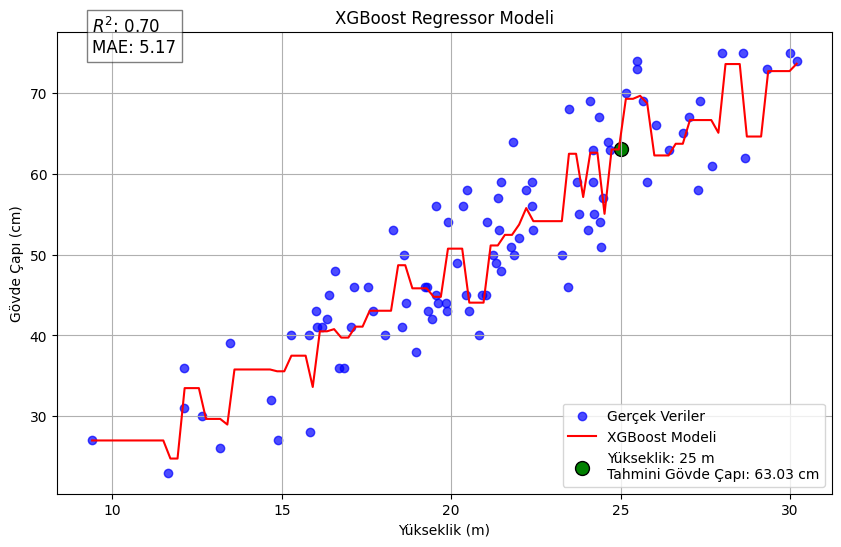

In [ ]:
# Bağımsız ve bağımlı değişkenleri ayırma
X = data[['Yükseklik (m)']].values
y = data['Gövde Çapı (cm)'].values

# Eğitim ve test veri setlerini ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# XGBoost Regressor modeli oluşturma ve eğitme
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
xgb_model.fit(X_train, y_train)

# Tahminler yapma
y_pred = xgb_model.predict(X_test)

# Performans metriklerini hesaplama
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

# Model performansını yazdırma
print(f"XGBoost Regressor Modeli Performansı:")
print(f"R²: {r2:.2f}")
print(f"MAE: {mae:.2f} (Ortalama Mutlak Hata)")
print(f"MSE: {mse:.2f} (Ortalama Kare Hata)")

# Örnek bir yükseklik değeri için tahmini gövde çapı hesaplama
user_height = 25  # Örnek yükseklik değeri
predicted_diameter = xgb_model.predict([[user_height]])
print(f"\nYükseklik {user_height} metre için tahmini Gövde Çapı: {predicted_diameter[0]:.2f} cm")

# Gerçek veriler ve XGBoost regresyon eğrisi ile görselleştirme
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Gerçek Veriler', alpha=0.7)

# XGBoost modelinin regresyon eğrisi
X_curve = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_curve = xgb_model.predict(X_curve)
plt.plot(X_curve, y_curve, color='red', label='XGBoost Modeli')

# R² değerini grafiğin üzerine ekleme
plt.text(x=float(X.min()), y=float(y.max()), s=f"$R^2$: {r2:.2f}\nMAE: {mae:.2f}", fontsize=12, color='black', bbox=dict(facecolor='white', alpha=0.5))

# Örnek bir yükseklik değeri için tahmini gösterme
plt.scatter(user_height, predicted_diameter, color='green', label=f'Yükseklik: 25 m\nTahmini Gövde Çapı: {predicted_diameter[0]:.2f} cm', s=100, edgecolor='black')

plt.xlabel('Yükseklik (m)')
plt.ylabel('Gövde Çapı (cm)')
plt.title('XGBoost Regressor Modeli')
plt.legend()
plt.grid()
plt.show()

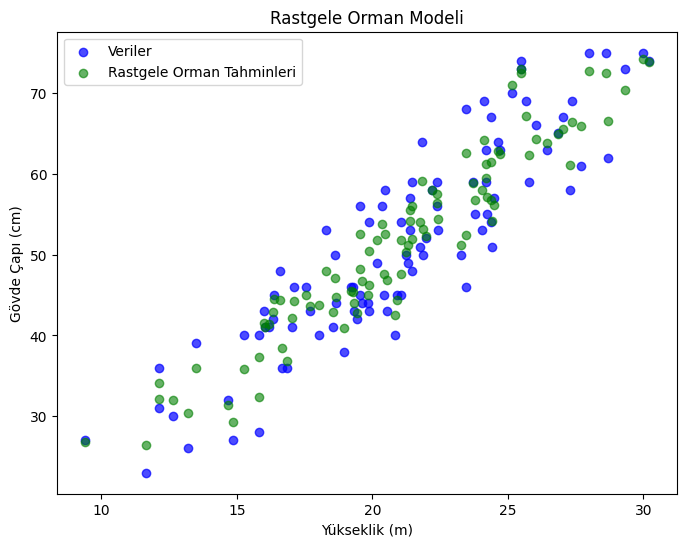

In [ ]:
X = data['Yükseklik (m)'].values.reshape(-1, 1)
y = data['Gövde Çapı (cm)'].values
# Model tanımlama ve eğitme
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X, y)

# Tahminler
y_pred_rf = rf_model.predict(X)

# Görselleştirme
plt.figure(figsize=(8, 6))
plt.scatter(X, y, color='blue', label='Veriler', alpha=0.7)
plt.scatter(X, y_pred_rf, color='green', label='Rastgele Orman Tahminleri', alpha=0.6)
plt.xlabel('Yükseklik (m)')
plt.ylabel('Gövde Çapı (cm)')
plt.title('Rastgele Orman Modeli')
plt.legend()
plt.show()

In [ ]:
# R², MAE ve MSE hesaplama
r2 = r2_score(y, y_pred_rf)
mae = mean_absolute_error(y, y_pred_rf)
mse = mean_squared_error(y, y_pred_rf)

print(f"R²: {r2:.2f}")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")

R²: 0.95
MAE: 2.19
MSE: 7.12


RandomForest Regressor Modeli Performansı:
R²: 0.95
MAE: 2.19 (Ortalama Mutlak Hata)
MSE: 7.12 (Ortalama Kare Hata)

Yükseklik 16.005 metre için tahmini Gövde Çapı: 41.57 cm


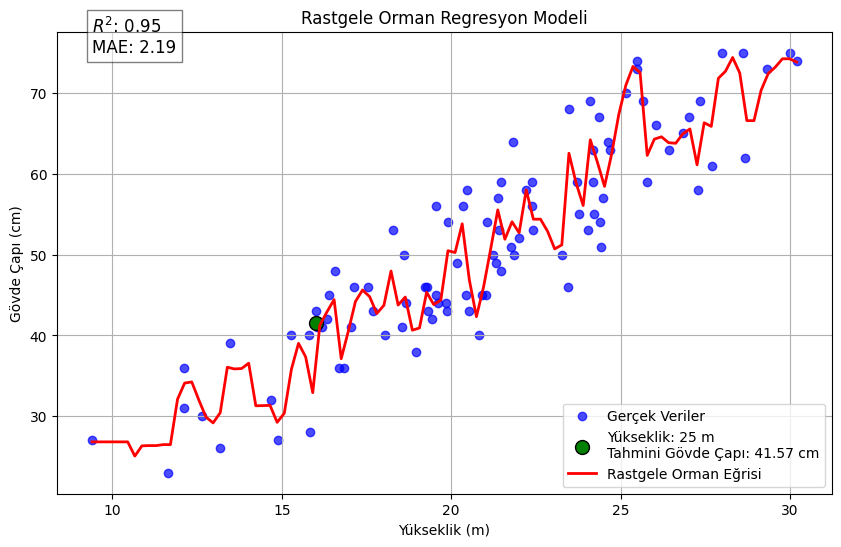

In [39]:
# Bağımsız ve bağımlı değişkenleri ayırma
X = data['Yükseklik (m)'].values.reshape(-1, 1)
y = data['Gövde Çapı (cm)'].values

# Model tanımlama ve eğitme
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X, y)

# Tahminler
y_pred_rf = rf_model.predict(X)

# Performans metriklerini hesaplama
r2 = r2_score(y, y_pred_rf)
mae = mean_absolute_error(y, y_pred_rf)
mse = mean_squared_error(y, y_pred_rf)

# Model performansını yazdırma
print(f"RandomForest Regressor Modeli Performansı:")
print(f"R²: {r2:.2f}")
print(f"MAE: {mae:.2f} (Ortalama Mutlak Hata)")
print(f"MSE: {mse:.2f} (Ortalama Kare Hata)")

# Örnek bir yükseklik değeri için tahmini gövde çapı hesaplama
user_height = 16.005  # Örnek yükseklik değeri
predicted_diameter = rf_model.predict([[user_height]])
print(f"\nYükseklik {user_height} metre için tahmini Gövde Çapı: {predicted_diameter[0]:.2f} cm")

# Gerçek veriler ve RandomForest regresyon eğrisi ile görselleştirme
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Gerçek Veriler', alpha=0.7)

# Eğri için daha fazla nokta üretme
X_curve = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_curve = rf_model.predict(X_curve)

# R² değerini grafiğin üzerine ekleme
plt.text(x=float(X.min()), y=float(y.max()), s=f"$R^2$: {r2:.2f}\nMAE: {mae:.2f}", fontsize=12, color='black', bbox=dict(facecolor='white', alpha=0.5))

# Örnek bir yükseklik değeri için tahmini gösterme
plt.scatter(user_height, predicted_diameter, color='green', label=f'Yükseklik: 25 m\nTahmini Gövde Çapı: {predicted_diameter[0]:.2f} cm', s=100, edgecolor='black')

# Görselleştirme
plt.plot(X_curve, y_curve, color='red', label='Rastgele Orman Eğrisi', linewidth=2)
plt.xlabel('Yükseklik (m)')
plt.ylabel('Gövde Çapı (cm)')
plt.title('Rastgele Orman Regresyon Modeli')
plt.legend()
plt.grid()
plt.show()

Regresyon Formülü: Gövde Çapı (cm) = 2.51 * Yükseklik (m) + -1.35
Doğrusal Regresyon Modeli Performansı:
R²: 0.81
MAE: 4.63 (Ortalama Mutlak Hata)
MSE: 30.37 (Ortalama Kare Hata)

Yükseklik 25 metre için tahmini Gövde Çapı: 61.31 cm


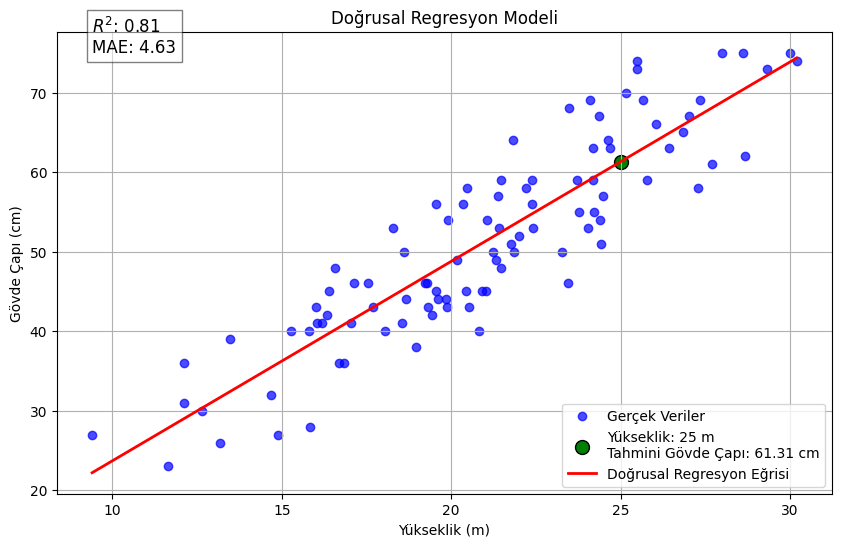

In [ ]:
# Bağımsız ve bağımlı değişkenleri ayırma
X = data['Yükseklik (m)'].values.reshape(-1, 1)
y = data['Gövde Çapı (cm)'].values

# Model tanımlama ve eğitme
lr_model = LinearRegression()
lr_model.fit(X, y)

# Modelin katsayılarını ve kesişimini öğrenme
a = lr_model.coef_[0]  # Katsayı
b = lr_model.intercept_  # Kesişim noktası
print(f"Regresyon Formülü: Gövde Çapı (cm) = {a:.2f} * Yükseklik (m) + {b:.2f}")

# Tahminler
y_pred_lr = lr_model.predict(X)

# Performans metriklerini hesaplama
r2 = r2_score(y, y_pred_lr)
mae = mean_absolute_error(y, y_pred_lr)
mse = mean_squared_error(y, y_pred_lr)

# Model performansını yazdırma
print(f"Doğrusal Regresyon Modeli Performansı:")
print(f"R²: {r2:.2f}")
print(f"MAE: {mae:.2f} (Ortalama Mutlak Hata)")
print(f"MSE: {mse:.2f} (Ortalama Kare Hata)")

# Örnek bir yükseklik değeri için tahmini gövde çapı hesaplama
user_height = 25  # Örnek yükseklik değeri
predicted_diameter = lr_model.predict([[user_height]])
print(f"\nYükseklik {user_height} metre için tahmini Gövde Çapı: {predicted_diameter[0]:.2f} cm")

# Gerçek veriler ve doğrusal regresyon eğrisi ile görselleştirme
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Gerçek Veriler', alpha=0.7)

# Eğri için daha fazla nokta üretme
X_curve = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_curve = lr_model.predict(X_curve)

# R² değerini grafiğin üzerine ekleme
plt.text(x=float(X.min()), y=float(y.max()), s=f"$R^2$: {r2:.2f}\nMAE: {mae:.2f}", fontsize=12, color='black', bbox=dict(facecolor='white', alpha=0.5))

# Örnek bir yükseklik değeri için tahmini gösterme
plt.scatter(user_height, predicted_diameter, color='green', label=f'Yükseklik: 25 m\nTahmini Gövde Çapı: {predicted_diameter[0]:.2f} cm', s=100, edgecolor='black')

# Görselleştirme
plt.plot(X_curve, y_curve, color='red', label='Doğrusal Regresyon Eğrisi', linewidth=2)
plt.xlabel('Yükseklik (m)')
plt.ylabel('Gövde Çapı (cm)')
plt.title('Doğrusal Regresyon Modeli')
plt.legend()
plt.grid()
plt.show()

Polinomsal Regresyon Formülü: Gövde Çapı (cm) = 0.01 * Yükseklik² + 1.91 * Yükseklik + 4.46
Polinomsal Regresyon Modeli Performansı (Derece 2):
R²: 0.81
MAE: 4.58 (Ortalama Mutlak Hata)
MSE: 30.24 (Ortalama Kare Hata)

Yükseklik 25 metre için tahmini Gövde Çapı: 61.30 cm


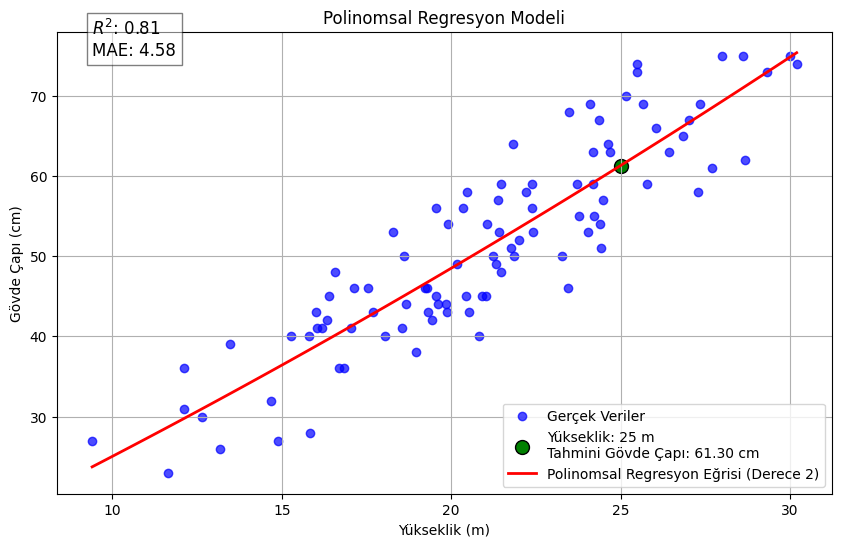

In [ ]:
# Bağımsız ve bağımlı değişkenleri ayırma
X = data['Yükseklik (m)'].values.reshape(-1, 1)
y = data['Gövde Çapı (cm)'].values

# Polinom özellikler oluşturma (derece 2)
degree = 2
poly = PolynomialFeatures(degree=degree)
X_poly = poly.fit_transform(X)

# Model tanımlama ve eğitme
poly_model = LinearRegression()
poly_model.fit(X_poly, y)

# Polinomsal regresyon formülü öğrenme
coefficients = poly_model.coef_
intercept = poly_model.intercept_
formula = f"Gövde Çapı (cm) = {coefficients[2]:.2f} * Yükseklik² + {coefficients[1]:.2f} * Yükseklik + {intercept:.2f}"
print(f"Polinomsal Regresyon Formülü: {formula}")

# Tahminler
y_pred_poly = poly_model.predict(X_poly)

# Performans metriklerini hesaplama
r2 = r2_score(y, y_pred_poly)
mae = mean_absolute_error(y, y_pred_poly)
mse = mean_squared_error(y, y_pred_poly)

# Model performansını yazdırma
print(f"Polinomsal Regresyon Modeli Performansı (Derece {degree}):")
print(f"R²: {r2:.2f}")
print(f"MAE: {mae:.2f} (Ortalama Mutlak Hata)")
print(f"MSE: {mse:.2f} (Ortalama Kare Hata)")

# Örnek bir yükseklik değeri için tahmini gövde çapı hesaplama
user_height = 25  # Örnek yükseklik değeri
user_height_poly = poly.transform([[user_height]])
predicted_diameter = poly_model.predict(user_height_poly)
print(f"\nYükseklik {user_height} metre için tahmini Gövde Çapı: {predicted_diameter[0]:.2f} cm")

# Gerçek veriler ve polinomsal regresyon eğrisi ile görselleştirme
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Gerçek Veriler', alpha=0.7)

# Eğri için daha fazla nokta üretme
X_curve = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_curve_poly = poly.transform(X_curve)
y_curve = poly_model.predict(X_curve_poly)

# R² değerini grafiğin üzerine ekleme
plt.text(x=float(X.min()), y=float(y.max()), s=f"$R^2$: {r2:.2f}\nMAE: {mae:.2f}", fontsize=12, color='black', bbox=dict(facecolor='white', alpha=0.5))

# Örnek bir yükseklik değeri için tahmini gösterme
plt.scatter(user_height, predicted_diameter, color='green', label=f'Yükseklik: 25 m\nTahmini Gövde Çapı: {predicted_diameter[0]:.2f} cm', s=100, edgecolor='black')

# Görselleştirme
plt.plot(X_curve, y_curve, color='red', label=f'Polinomsal Regresyon Eğrisi (Derece {degree})', linewidth=2)
plt.xlabel('Yükseklik (m)')
plt.ylabel('Gövde Çapı (cm)')
plt.title('Polinomsal Regresyon Modeli')
plt.legend()
plt.grid()
plt.show()

Logaritmik Regresyon Formülü: Gövde Çapı (cm) = 47.90 * ln(Yükseklik) + -93.38
Logaritmik Regresyon Modeli Performansı:
R²: 0.78
MAE: 5.04 (Ortalama Mutlak Hata)
MSE: 34.76 (Ortalama Kare Hata)

Yükseklik 25 metre için tahmini Gövde Çapı: 60.82 cm


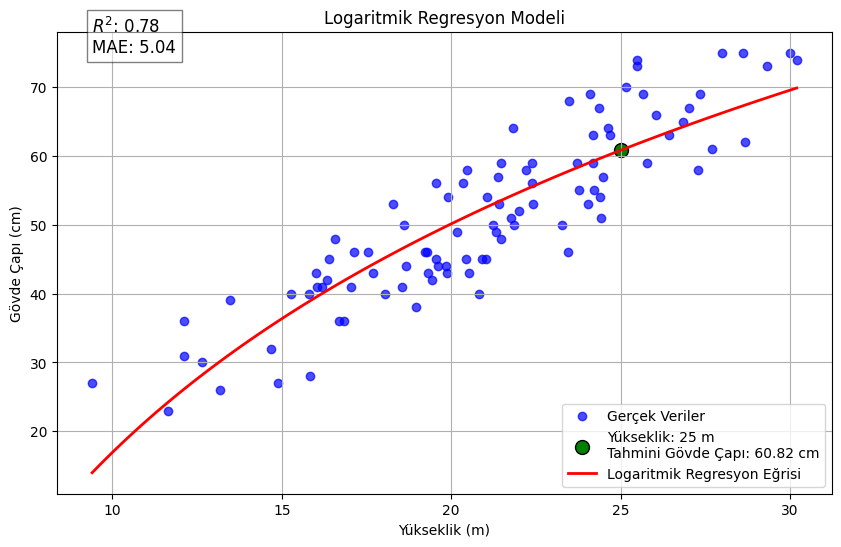

In [ ]:
# Bağımsız ve bağımlı değişkenleri ayırma (logaritmik dönüşüm)
X = np.log(data['Yükseklik (m)'].values).reshape(-1, 1)
y = data['Gövde Çapı (cm)'].values

# Model tanımlama ve eğitme
log_model = LinearRegression()
log_model.fit(X, y)

# Logaritmik regresyon formülü öğrenme
a = log_model.coef_[0]  # Katsayı
b = log_model.intercept_  # Kesişim noktası
formula = f"Gövde Çapı (cm) = {a:.2f} * ln(Yükseklik) + {b:.2f}"
print(f"Logaritmik Regresyon Formülü: {formula}")

# Tahminler
y_pred_log = log_model.predict(X)

# Performans metriklerini hesaplama
r2 = r2_score(y, y_pred_log)
mae = mean_absolute_error(y, y_pred_log)
mse = mean_squared_error(y, y_pred_log)

# Model performansını yazdırma
print(f"Logaritmik Regresyon Modeli Performansı:")
print(f"R²: {r2:.2f}")
print(f"MAE: {mae:.2f} (Ortalama Mutlak Hata)")
print(f"MSE: {mse:.2f} (Ortalama Kare Hata)")

# Örnek bir yükseklik değeri için tahmini gövde çapı hesaplama
user_height = 25  # Örnek yükseklik değeri
user_log_height = np.log(user_height).reshape(1, -1)
predicted_diameter = log_model.predict(user_log_height)
print(f"\nYükseklik {user_height} metre için tahmini Gövde Çapı: {predicted_diameter[0]:.2f} cm")

# Gerçek veriler ve logaritmik regresyon eğrisi ile görselleştirme
plt.figure(figsize=(10, 6))
plt.scatter(data['Yükseklik (m)'], y, color='blue', label='Gerçek Veriler', alpha=0.7)

# Eğri için daha fazla nokta üretme
X_curve = np.linspace(data['Yükseklik (m)'].min(), data['Yükseklik (m)'].max(), 100).reshape(-1, 1)
X_curve_log = np.log(X_curve)
y_curve = log_model.predict(X_curve_log)

# R² değerini grafiğin üzerine ekleme
plt.text(x=data['Yükseklik (m)'].min(), y=max(y), s=f"$R^2$: {r2:.2f}\nMAE: {mae:.2f}", fontsize=12, color='black', bbox=dict(facecolor='white', alpha=0.5))

# Örnek bir yükseklik değeri için tahmini gösterme
plt.scatter(user_height, predicted_diameter, color='green', label=f'Yükseklik: 25 m\nTahmini Gövde Çapı: {predicted_diameter[0]:.2f} cm', s=100, edgecolor='black')

# Görselleştirme
plt.plot(X_curve, y_curve, color='red', label='Logaritmik Regresyon Eğrisi', linewidth=2)
plt.xlabel('Yükseklik (m)')
plt.ylabel('Gövde Çapı (cm)')
plt.title('Logaritmik Regresyon Modeli')
plt.legend()
plt.grid()
plt.show()

Destek Vektör Regresyon Modeli Performansı:
R²: 0.80
MAE: 4.31 (Ortalama Mutlak Hata)
MSE: 30.84 (Ortalama Kare Hata)

Yükseklik 25 metre için tahmini Gövde Çapı: 62.90 cm


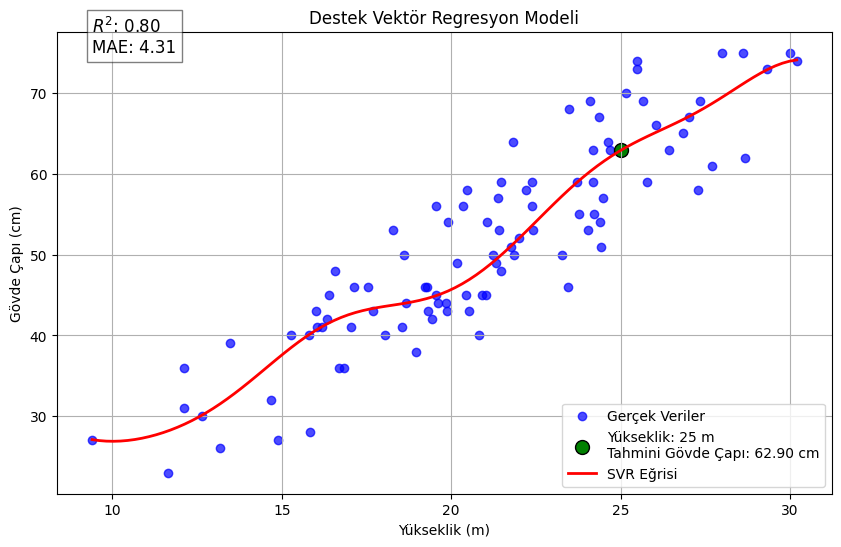

In [ ]:
# Bağımsız ve bağımlı değişkenleri ayırma
X = data['Yükseklik (m)'].values.reshape(-1, 1)
y = data['Gövde Çapı (cm)'].values

# Destek Vektör Regresyon modeli tanımlama ve eğitme
svr_model = SVR(kernel='rbf', C=100, epsilon=0.1)
svr_model.fit(X, y)

# Tahminler
y_pred_svr = svr_model.predict(X)

# Performans metriklerini hesaplama
r2 = r2_score(y, y_pred_svr)
mae = mean_absolute_error(y, y_pred_svr)
mse = mean_squared_error(y, y_pred_svr)

# Model performansını yazdırma
print(f"Destek Vektör Regresyon Modeli Performansı:")
print(f"R²: {r2:.2f}")
print(f"MAE: {mae:.2f} (Ortalama Mutlak Hata)")
print(f"MSE: {mse:.2f} (Ortalama Kare Hata)")

# Örnek bir yükseklik değeri için tahmini gövde çapı hesaplama
user_height = 25  # Örnek yükseklik değeri
predicted_diameter = svr_model.predict([[user_height]])
print(f"\nYükseklik {user_height} metre için tahmini Gövde Çapı: {predicted_diameter[0]:.2f} cm")

# Gerçek veriler ve SVR eğrisi ile görselleştirme
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Gerçek Veriler', alpha=0.7)

# Eğri için daha fazla nokta üretme
X_curve = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_curve = svr_model.predict(X_curve)

# R² değerini grafiğin üzerine ekleme
plt.text(x=float(X.min()), y=max(y), s=f"$R^2$: {r2:.2f}\nMAE: {mae:.2f}", fontsize=12, color='black', bbox=dict(facecolor='white', alpha=0.5))

# Örnek bir yükseklik değeri için tahmini gösterme
plt.scatter(user_height, predicted_diameter, color='green', label=f'Yükseklik: 25 m\nTahmini Gövde Çapı: {predicted_diameter[0]:.2f} cm', s=100, edgecolor='black')

# Görselleştirme
plt.plot(X_curve, y_curve, color='red', label='SVR Eğrisi', linewidth=2)
plt.xlabel('Yükseklik (m)')
plt.ylabel('Gövde Çapı (cm)')
plt.title('Destek Vektör Regresyon Modeli')
plt.legend()
plt.grid()
plt.show()

XGBoost Regresyon Modeli Performansı:
R²: 0.93
MAE: 2.63 (Ortalama Mutlak Hata)
MSE: 10.77 (Ortalama Kare Hata)

Yükseklik 16.005 metre için tahmini Gövde Çapı: 41.64 cm


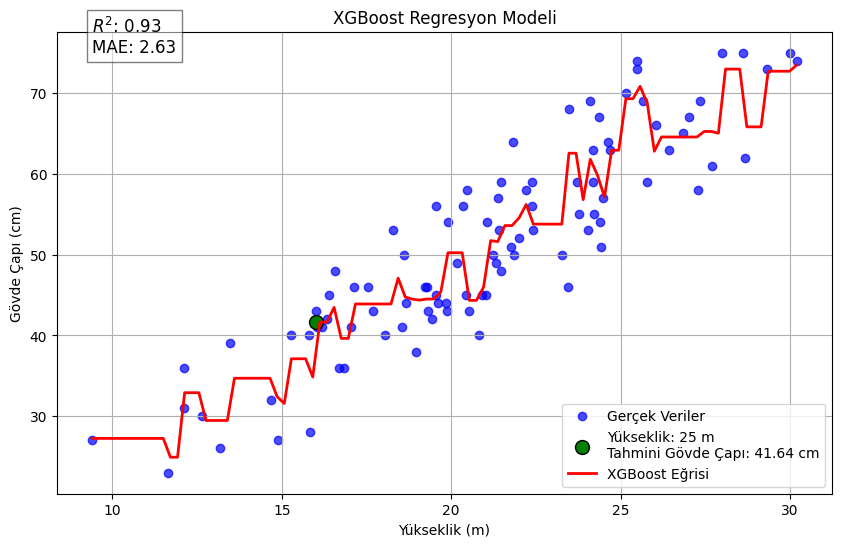

In [44]:
# Bağımsız ve bağımlı değişkenleri ayırma
X = data['Yükseklik (m)'].values.reshape(-1, 1)
y = data['Gövde Çapı (cm)'].values

# XGBoost Regresyon modeli tanımlama ve eğitme
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
xgb_model.fit(X, y)

# Tahminler
y_pred_xgb = xgb_model.predict(X)

# Performans metriklerini hesaplama
r2 = r2_score(y, y_pred_xgb)
mae = mean_absolute_error(y, y_pred_xgb)
mse = mean_squared_error(y, y_pred_xgb)

# Model performansını yazdırma
print(f"XGBoost Regresyon Modeli Performansı:")
print(f"R²: {r2:.2f}")
print(f"MAE: {mae:.2f} (Ortalama Mutlak Hata)")
print(f"MSE: {mse:.2f} (Ortalama Kare Hata)")

# Örnek bir yükseklik değeri için tahmini gövde çapı hesaplama
user_height = 16.005   # Örnek yükseklik değeri
predicted_diameter = xgb_model.predict([[user_height]])
print(f"\nYükseklik {user_height} metre için tahmini Gövde Çapı: {predicted_diameter[0]:.2f} cm")

# Gerçek veriler ve XGBoost eğrisi ile görselleştirme
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Gerçek Veriler', alpha=0.7)

# Eğri için daha fazla nokta üretme
X_curve = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_curve = xgb_model.predict(X_curve)

# R² değerini grafiğin üzerine ekleme
plt.text(x=float(X.min()), y=max(y), s=f"$R^2$: {r2:.2f}\nMAE: {mae:.2f}", fontsize=12, color='black', bbox=dict(facecolor='white', alpha=0.5))

# Örnek bir yükseklik değeri için tahmini gösterme
plt.scatter(user_height, predicted_diameter, color='green', label=f'Yükseklik: 25 m\nTahmini Gövde Çapı: {predicted_diameter[0]:.2f} cm', s=100, edgecolor='black')

# Görselleştirme
plt.plot(X_curve, y_curve, color='red', label='XGBoost Eğrisi', linewidth=2)
plt.xlabel('Yükseklik (m)')
plt.ylabel('Gövde Çapı (cm)')
plt.title('XGBoost Regresyon Modeli')
plt.legend()
plt.grid()
plt.show()

<ipython-input-71-ceeed1eee5f3>:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([X, y], labels=['Yükseklik (m)', 'Gövde Çapı (cm)'])
<ipython-input-71-ceeed1eee5f3>:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([X.ravel(), y], labels=['Yükseklik (m)', 'Gövde Çapı (cm)'])  # Flatten X using ravel()


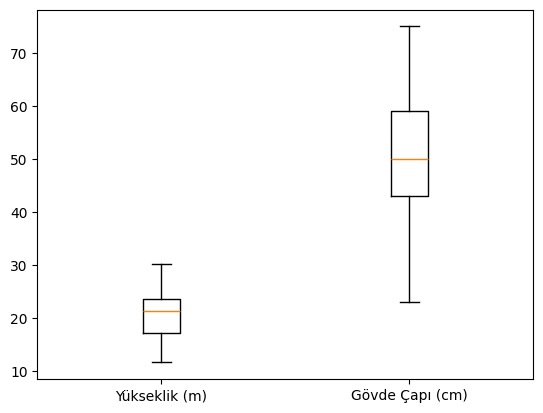

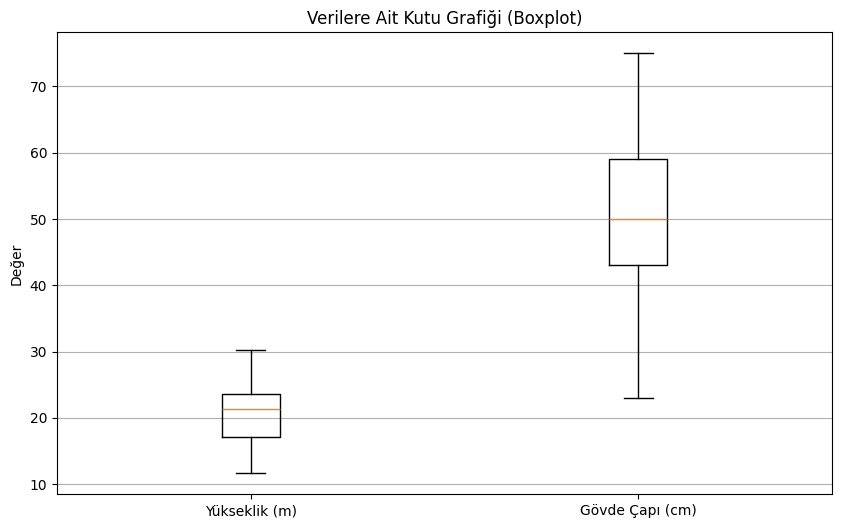

In [ ]:
X = data['Yükseklik (m)'].values

plt.boxplot([X, y], labels=['Yükseklik (m)', 'Gövde Çapı (cm)'])

plt.figure(figsize=(10, 6))
plt.boxplot([X.ravel(), y], labels=['Yükseklik (m)', 'Gövde Çapı (cm)'])  # Flatten X using ravel()
plt.title('Verilere Ait Kutu Grafiği (Boxplot)')
plt.ylabel('Değer')
plt.grid(axis='y')
plt.show()


<ipython-input-72-dd786485ec87>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data_long, x='Parametre', y='Değer', palette='Set2')


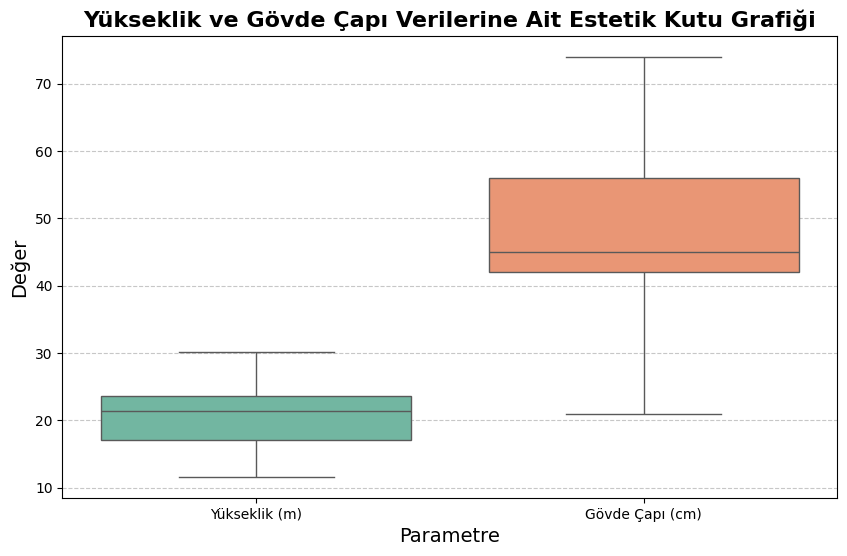

In [ ]:
# Verileri uzun formata çevirme
data_long = pd.DataFrame({
    'Değer': np.concatenate([data['Yükseklik (m)'], data['Gövde Çapı (cm)']]),
    'Parametre': ['Yükseklik (m)'] * len(data['Yükseklik (m)']) + ['Gövde Çapı (cm)'] * len(data['Gövde Çapı (cm)'])
})

# Seaborn ile estetik kutu grafiği
plt.figure(figsize=(10, 6))
sns.boxplot(data=data_long, x='Parametre', y='Değer', palette='Set2')

# Grafik detayları
plt.title('Yükseklik ve Gövde Çapı Verilerine Ait Estetik Kutu Grafiği', fontsize=16, fontweight='bold')
plt.xlabel('Parametre', fontsize=14)
plt.ylabel('Değer', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Uç değerleri bulmak için alt ve üst sınırları hesaplama
Q1 = data['Yükseklik (m)'].quantile(0.25)  # 1. Çeyrek
Q3 = data['Yükseklik (m)'].quantile(0.75)  # 3. Çeyrek
IQR = Q3 - Q1  # Çeyrekler arası aralık

# Alt ve üst sınırlar
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Yükseklik için uç değerleri kaldırma
data_no_outliers = data[(data['Yükseklik (m)'] >= lower_bound) & (data['Yükseklik (m)'] <= upper_bound)]

# Aynı işlemi gövde çapı için yapabilirsiniz
Q1_diameter = data['Gövde Çapı (cm)'].quantile(0.25)
Q3_diameter = data['Gövde Çapı (cm)'].quantile(0.75)
IQR_diameter = Q3_diameter - Q1_diameter

lower_bound_diameter = Q1_diameter - 1.5 * IQR_diameter
upper_bound_diameter = Q3_diameter + 1.5 * IQR_diameter

data_no_outliers = data_no_outliers[
    (data_no_outliers['Gövde Çapı (cm)'] >= lower_bound_diameter) &
    (data_no_outliers['Gövde Çapı (cm)'] <= upper_bound_diameter)
]


<ipython-input-6-39f692ecab9d>:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


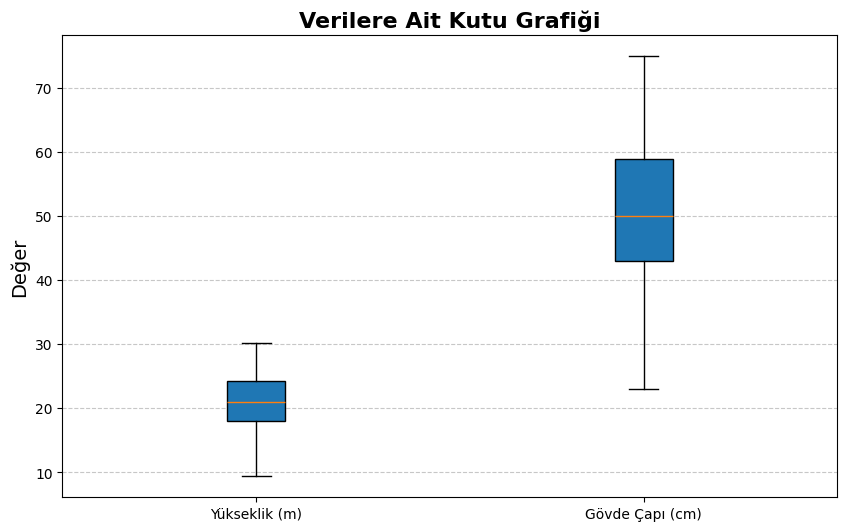

In [ ]:
# Uç değerleri kaldırılmış veriyle kutu grafiği
plt.figure(figsize=(10, 6))
plt.boxplot(
    [data_no_outliers['Yükseklik (m)'], data_no_outliers['Gövde Çapı (cm)']],
    labels=['Yükseklik (m)', 'Gövde Çapı (cm)'],
    patch_artist=True
)

# Grafik detayları
plt.title('Verilere Ait Kutu Grafiği', fontsize=16, fontweight='bold')
plt.ylabel('Değer', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()